# Quick G/H/A Validation

This notebook builds the explicit weight-space matrices for the implemented EFGP system.

- Implemented formula: `A = D (F^* F) D + lambda I`, with `Phi = F D`.
- Here `G = F^* F`, `H = D G D`, `A = H + lambda I`.
- We keep `dim = 1` and use a rough `eps = 3e-4`, so `M` is around `10^2`.
- Datasets: synthetic 1D and real 1D household power.


In [223]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_cwd = Path.cwd().resolve()
_candidates = [_cwd, *_cwd.parents, Path(r"D:/NU/ML")]
for _p in _candidates:
    if (_p / "efgp_eigenpro_py").exists():
        ROOT = _p
        break
else:
    raise RuntimeError("Could not locate repo root.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from efgp_eigenpro_py.benchmark import make_dataset, true_func_1d
from efgp_eigenpro_py.discretization import generate_multi_index
from efgp_eigenpro_py.efgp_solver import EFGPSolver
from efgp_eigenpro_py.kernels import make_matern

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", 50)
print("ROOT:", ROOT)


ROOT: D:\NU\ML


In [224]:
REAL_NPZ = ROOT / "efgp_eigenpro_py" / "gpu" / "benchmark_dataset" / "processed" / "household_power_consumption_global_active_power_d1_time.npz"

KERNEL = make_matern(lengthscale=0.1, nu=1.5, dim=1, variance=1.0)
REG_LAMBDA = 0.1
EPS = 3e-4
NUFFT_TOL = 1e-10
L2_SCALED = True

N_SYN = 2048
N_REAL = 4096


def hermitian_part(M):
    return 0.5 * (M + M.conj().T)


def load_real_subset(npz_path, n_use=4096):
    data = np.load(npz_path)
    x = np.asarray(data["x_train"], dtype=np.float64).reshape(-1, 1)
    y = np.asarray(data["y_train"], dtype=np.float64).reshape(-1)
    order = np.argsort(x[:, 0])
    x = x[order]
    y = y[order]
    n_use = min(int(n_use), int(x.shape[0]))
    idx = np.linspace(0, x.shape[0] - 1, n_use, dtype=int)
    return x[idx], y[idx]


def safe_positive_cond(eigvals, rel_tol=1e-12):
    eigvals = np.real(np.asarray(eigvals))
    vmax = float(np.max(eigvals))
    thresh = rel_tol * max(vmax, 1.0)
    pos = eigvals[eigvals > thresh]
    if pos.size == 0:
        return np.inf
    return float(np.max(pos) / np.min(pos))


def r2_score(y, yhat):
    y = np.asarray(y)
    yhat = np.asarray(yhat)
    ss_res = float(np.sum((y - yhat) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return 1.0 - ss_res / max(ss_tot, 1e-30)


def fit_decay(abs_j, D):
    abs_j = np.asarray(abs_j, dtype=np.float64)
    D = np.abs(np.asarray(D, dtype=np.float64))
    mask = abs_j > 0
    x = abs_j[mask]
    y = D[mask]
    logy = np.log(y)

    expo_coef = np.polyfit(x, logy, deg=1)
    expo_pred = np.polyval(expo_coef, x)

    poly_coef = np.polyfit(np.log(x), logy, deg=1)
    poly_pred = np.polyval(poly_coef, np.log(x))

    expo_r2 = r2_score(logy, expo_pred)
    poly_r2 = r2_score(logy, poly_pred)
    winner = "polynomial-like" if poly_r2 > expo_r2 else "exponential-like"

    return {
        "winner": winner,
        "expo_r2": float(expo_r2),
        "poly_r2": float(poly_r2),
        "expo_coef": expo_coef,
        "poly_coef": poly_coef,
    }


def build_explicit_gha(solver, x, y):
    state = solver.precompute(x, y)
    hm = (state.grid.mtot - 1) // 2
    J = generate_multi_index(hm, solver.kernel.dim)
    tphx = solver._scale_from_center(x, state.x_center, state.grid.h)
    F = np.exp(1j * (tphx @ J.T))
    D = np.asarray(state.weights, dtype=np.float64).reshape(-1)
    G = hermitian_part(F.conj().T @ F)
    H = hermitian_part((D[:, None] * G) * D[None, :])
    A = hermitian_part(H + solver.reg_lambda * np.eye(H.shape[0], dtype=np.complex128))
    return state, J, F, D, G, H, A


def analyze_case(name, x, y):
    solver = EFGPSolver(
        KERNEL,
        reg_lambda=REG_LAMBDA,
        eps=EPS,
        nufft_tol=NUFFT_TOL,
        l2scaled=L2_SCALED,
    )
    state, J, F, D, G, H, A = build_explicit_gha(solver, x, y)

    Phi = F * D[None, :]
    A_from_phi = hermitian_part(Phi.conj().T @ Phi + REG_LAMBDA * np.eye(Phi.shape[1], dtype=np.complex128))
    A_formula_err = float(np.linalg.norm(A - A_from_phi) / max(np.linalg.norm(A_from_phi), 1e-30))

    rng = np.random.default_rng(0)
    v = rng.standard_normal(D.size) + 1j * rng.standard_normal(D.size)
    Av_explicit = A @ v
    Av_solver = solver._apply_A(state, v)
    matvec_err = float(np.linalg.norm(Av_explicit - Av_solver) / max(np.linalg.norm(Av_solver), 1e-30))

    eig_G = np.linalg.eigvalsh(G)
    eig_H = np.linalg.eigvalsh(H)
    eig_A = np.linalg.eigvalsh(A)

    diag_G = np.real(np.diag(G))
    abs_j = np.abs(J[:, 0])
    decay = fit_decay(abs_j, D)

    summary = {
        "dataset": name,
        "N": int(x.shape[0]),
        "M": int(D.size),
        "h": float(state.grid.h),
        "hm": int(state.grid.hm),
        "diag_G_mean": float(diag_G.mean()),
        "diag_G_std": float(diag_G.std()),
        "diag_G_rel_std": float(diag_G.std() / max(abs(diag_G.mean()), 1e-30)),
        "expected_diag_G": float(x.shape[0]),
        "D_min": float(np.min(D)),
        "D_max": float(np.max(D)),
        "D_decay_best_fit": decay["winner"],
        "D_decay_poly_r2": decay["poly_r2"],
        "D_decay_expo_r2": decay["expo_r2"],
        "cond_G_np": float(np.linalg.cond(G)),
        "cond_H_np": float(np.linalg.cond(H)),
        "cond_A_np": float(np.linalg.cond(A)),
        "cond_G_pos": safe_positive_cond(eig_G),
        "cond_H_pos": safe_positive_cond(eig_H),
        "cond_A_pos": safe_positive_cond(eig_A),
        "A_formula_relerr": A_formula_err,
        "A_matvec_relerr": matvec_err,
    }

    return {
        "summary": summary,
        "x": x,
        "y": y,
        "state": state,
        "J": J,
        "F": F,
        "D": D,
        "G": G,
        "H": H,
        "A": A,
        "eig_G": eig_G,
        "eig_H": eig_H,
        "eig_A": eig_A,
        "decay": decay,
    }


In [225]:
x_syn, y_syn = make_dataset(1, N_SYN, true_func_1d, noise=0.02, seed=0)
x_real, y_real = load_real_subset(REAL_NPZ, n_use=N_REAL)

results = {
    "synthetic_1d": analyze_case("synthetic_1d", x_syn, y_syn),
    "real_household_d1": analyze_case("real_household_d1", x_real, y_real),
}

summary_df = pd.DataFrame([results[k]["summary"] for k in results])
summary_df = summary_df[
    [
        "dataset",
        "N",
        "M",
        "h",
        "hm",
        "diag_G_mean",
        "diag_G_std",
        "diag_G_rel_std",
        "expected_diag_G",
        "D_decay_best_fit",
        "D_decay_poly_r2",
        "D_decay_expo_r2",
        "cond_G_np",
        "cond_H_np",
        "cond_A_np",
        "cond_G_pos",
        "cond_H_pos",
        "cond_A_pos",
        "A_formula_relerr",
        "A_matvec_relerr",
    ]
]
summary_df


,dataset,N,M,h,hm,diag_G_mean,diag_G_std,diag_G_rel_std,expected_diag_G,D_decay_best_fit,D_decay_poly_r2,D_decay_expo_r2,cond_G_np,cond_H_np,cond_A_np,cond_G_pos,cond_H_pos,cond_A_pos,A_formula_relerr,A_matvec_relerr
0,synthetic_1d,2048,103,0.609207,51,2048.0,2.240379e-14,1.093935e-17,2048.0,polynomial-like,0.955317,0.930525,9.909256e+16,1.121468e+20,4467.139872,3.292126e+11,2.269708e+11,4467.139872,6.695210e-16,1.624931e-12
1,real_household_d1,4096,103,0.608952,51,4096.0,0.000000e+00,0.000000e+00,4096.0,polynomial-like,0.955291,0.930554,8.782195e+16,1.973578e+20,9056.021505,2.379547e+11,2.467416e+11,9056.021505,1.204721e-15,1.608549e-13


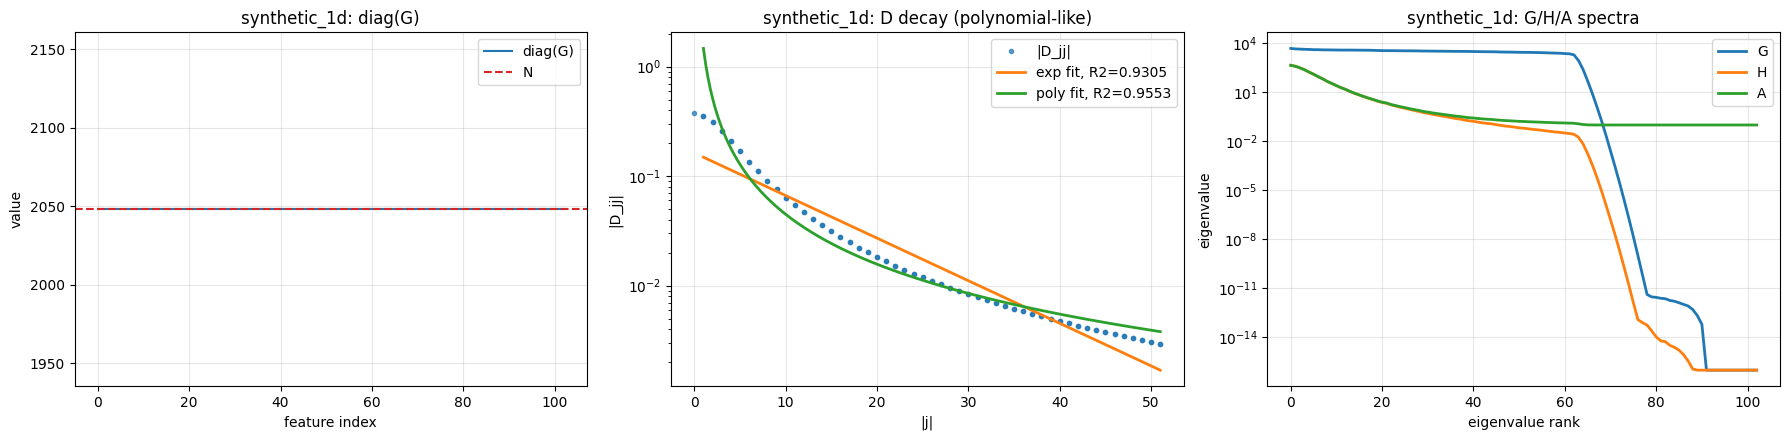

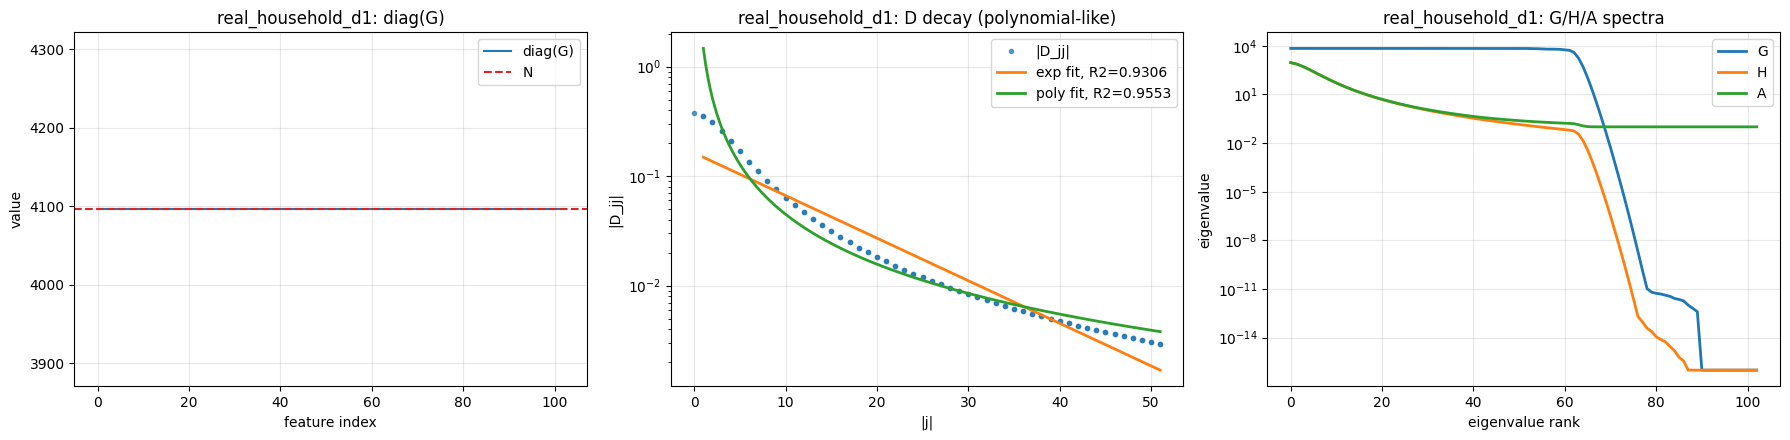

In [226]:
for name, res in results.items():
    diag_G = np.real(np.diag(res["G"]))
    abs_j = np.abs(res["J"][:, 0]).astype(float)
    D = np.abs(res["D"])
    decay = res["decay"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].plot(diag_G, lw=1.5, label="diag(G)")
    axes[0].axhline(res["x"].shape[0], color="tab:red", ls="--", label="N")
    axes[0].set_title(f"{name}: diag(G)")
    axes[0].set_xlabel("feature index")
    axes[0].set_ylabel("value")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    order = np.argsort(abs_j)
    axes[1].semilogy(abs_j[order], D[order], "o", ms=3, alpha=0.7, label="|D_jj|")
    xfit = np.linspace(1.0, max(1.0, abs_j.max()), 200)
    yfit_expo = np.exp(np.polyval(decay["expo_coef"], xfit))
    yfit_poly = np.exp(np.polyval(decay["poly_coef"], np.log(xfit)))
    axes[1].semilogy(xfit, yfit_expo, lw=2, label=f"exp fit, R2={decay['expo_r2']:.4f}")
    axes[1].semilogy(xfit, yfit_poly, lw=2, label=f"poly fit, R2={decay['poly_r2']:.4f}")
    axes[1].set_title(f"{name}: D decay ({decay['winner']})")
    axes[1].set_xlabel("|j|")
    axes[1].set_ylabel("|D_jj|")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    for label, eigvals in [("G", res["eig_G"]), ("H", res["eig_H"]), ("A", res["eig_A"])]:
        vals = np.sort(np.real(eigvals))[::-1]
        vals = np.maximum(vals, 1e-16)
        axes[2].semilogy(vals, lw=2, label=label)
    axes[2].set_title(f"{name}: G/H/A spectra")
    axes[2].set_xlabel("eigenvalue rank")
    axes[2].set_ylabel("eigenvalue")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    fig.tight_layout()
    plt.show()


In [227]:
for name, res in results.items():
    s = res["summary"]
    print("=" * 80)
    print(name)
    print(f"M={s['M']}, h={s['h']:.6g}, hm={s['hm']}")
    print(f"diag(G) mean={s['diag_G_mean']:.6g}, std={s['diag_G_std']:.3e}, expected N={s['expected_diag_G']:.0f}")
    print(f"D decay best fit: {s['D_decay_best_fit']} (poly R2={s['D_decay_poly_r2']:.4f}, exp R2={s['D_decay_expo_r2']:.4f})")
    print(f"cond(G)={s['cond_G_np']:.6g}, cond(H)={s['cond_H_np']:.6g}, cond(A)={s['cond_A_np']:.6g}")
    print(f"positive-spectrum conds: G={s['cond_G_pos']:.6g}, H={s['cond_H_pos']:.6g}, A={s['cond_A_pos']:.6g}")
    print(f"A formula relerr={s['A_formula_relerr']:.3e}, solver matvec relerr={s['A_matvec_relerr']:.3e}")


synthetic_1d
M=103, h=0.609207, hm=51
diag(G) mean=2048, std=2.240e-14, expected N=2048
D decay best fit: polynomial-like (poly R2=0.9553, exp R2=0.9305)
cond(G)=9.90926e+16, cond(H)=1.12147e+20, cond(A)=4467.14
positive-spectrum conds: G=3.29213e+11, H=2.26971e+11, A=4467.14
A formula relerr=6.695e-16, solver matvec relerr=1.625e-12
real_household_d1
M=103, h=0.608952, hm=51
diag(G) mean=4096, std=0.000e+00, expected N=4096
D decay best fit: polynomial-like (poly R2=0.9553, exp R2=0.9306)
cond(G)=8.78219e+16, cond(H)=1.97358e+20, cond(A)=9056.02
positive-spectrum conds: G=2.37955e+11, H=2.46742e+11, A=9056.02
A formula relerr=1.205e-15, solver matvec relerr=1.609e-13


## Combo Benchmark: Method 2 + EigenPro

This section tests the complementary effect of
`Method 2 = symmetric diagonal scaling` and `EigenPro`.

We compare four families:

- `baseline_cg`: plain CG on `A x = b`
- `pure_eigenpro`: EigenPro on the original `A`
- `pure_method2`: CG on the scaled system `P2 A P2 y = P2 b`, then `x = P2 y`
- `combo_method2_eigenpro`: EigenPro on the scaled system `A_tilde = P2 A P2`

We use
`P2 = diag(N * |D_jj|^2 + lambda)^(-1/2)`
as the first-layer global scaling.

Notes:
- For `M ~ 10^3`, we also compute dense condition numbers for `A` and `P2 A P2`.
- For `M ~ 10^4`, we stay matrix-free and focus on iteration/time comparisons.
- This block is intentionally synthetic-first, so it stays simple and fast to rerun.


In [228]:
import time

from scipy.sparse.linalg import ArpackNoConvergence

from efgp_eigenpro_py.benchmark import pcg_solve
from efgp_eigenpro_py.eigenpro_precond import build_preconditioner
from efgp_eigenpro_py.eigenspace import EigenPairs, estimate_top_eigenspace


COMBO_KERNEL = make_matern(lengthscale=0.1, nu=1.5, dim=1, variance=1.0)
COMBO_REG_LAMBDA = 0.1
COMBO_NUFFT_TOL = 1e-10
COMBO_L2_SCALED = True
COMBO_SOLVE_TOL = 1e-8
COMBO_MAXITER = 4000
COMBO_EIG_TOL = 1e-4
COMBO_EIG_MAXITER = 8
COMBO_EIG_METHOD = "eigsh"
COMBO_EIG_FALLBACK_METHOD = "subspace_iter"
COMBO_TOPK_LIST = [4, 8, 16, 32]

# M around 1e3 and 1e4.
COMBO_EPS_MEDIUM = 3e-7   # M ~= 937
COMBO_EPS_LARGE = 1e-10   # M ~= 11619
COMBO_N_MEDIUM = 4096
COMBO_N_LARGE = 8192


def make_combo_problem(eps, n_samples, seed=123):
    x, y = make_dataset(1, n_samples, true_func_1d, noise=0.02, seed=seed)
    solver = EFGPSolver(
        COMBO_KERNEL,
        reg_lambda=COMBO_REG_LAMBDA,
        eps=eps,
        nufft_tol=COMBO_NUFFT_TOL,
        l2scaled=COMBO_L2_SCALED,
    )
    state = solver.precompute(x, y)
    return x, y, solver, state


def make_scaled_system(state, solver):
    rhs = np.asarray(state.rhs, dtype=np.complex128)
    D = np.asarray(state.weights, dtype=np.float64).reshape(-1)
    N = int(rhs.size)  # placeholder, overwritten below when caller has x
    return rhs, D, N


def build_method2_scaler(x, state):
    D = np.asarray(state.weights, dtype=np.float64).reshape(-1)
    N = int(x.shape[0])
    p2 = 1.0 / np.sqrt(N * (np.abs(D) ** 2) + COMBO_REG_LAMBDA)
    return np.asarray(p2, dtype=np.float64)


def make_scaled_matvec(solver, state, p2):
    p2 = np.asarray(p2, dtype=np.complex128).reshape(-1)

    def amat(v):
        vv = np.asarray(v, dtype=np.complex128).reshape(-1)
        return np.asarray(solver._apply_A(state, vv), dtype=np.complex128)

    def atilde(v):
        vv = np.asarray(v, dtype=np.complex128).reshape(-1)
        return p2 * amat(p2 * vv)

    return amat, atilde


def dense_from_state(x, state, solver):
    hm = (state.grid.mtot - 1) // 2
    J = generate_multi_index(hm, solver.kernel.dim)
    tphx = solver._scale_from_center(x, state.x_center, state.grid.h)
    F = np.exp(1j * (tphx @ J.T))
    D = np.asarray(state.weights, dtype=np.float64).reshape(-1)
    G = hermitian_part(F.conj().T @ F)
    H = hermitian_part((D[:, None] * G) * D[None, :])
    A = hermitian_part(H + solver.reg_lambda * np.eye(H.shape[0], dtype=np.complex128))
    return G, H, A, D


def run_pcg_case(matvec, rhs, precond=None, tol=COMBO_SOLVE_TOL, maxiter=COMBO_MAXITER):
    t0 = time.perf_counter()
    x, it, relres, _hist, stats = pcg_solve(
        matvec,
        rhs,
        tol=tol,
        maxiter=maxiter,
        precond=precond,
        store_history=False,
        return_stats=True,
    )
    t1 = time.perf_counter()
    out = {
        "x": x,
        "iters": int(it),
        "relres": float(relres),
        "time_solve": float(t1 - t0),
        "n_matvec": int(stats["n_matvec"]),
        "n_precond": int(stats["n_precond"]),
        "t_matvec_total": float(stats["t_matvec_total"]),
        "t_precond_total": float(stats["t_precond_total"]),
    }
    return out


def _safe_mu_from_eigpairs(eigpairs, top_k):
    eigvals_top = np.asarray(np.real(eigpairs.values[:top_k]), dtype=float)
    mu_candidate = float(np.real(eigpairs.values[top_k]))
    mu_upper = float(np.min(eigvals_top))
    mu = min(mu_candidate, mu_upper * (1.0 - 1e-12))
    mu = max(mu, mu_upper * 1e-12)
    return eigvals_top, mu


def eigenpro_from_dense_matrix(A_dense, top_k):
    vals, vecs = np.linalg.eigh(hermitian_part(A_dense))
    order = np.argsort(vals)[::-1]
    eigpairs = EigenPairs(values=np.asarray(vals[order]), vectors=np.asarray(vecs[:, order]))
    eigvals_top, mu = _safe_mu_from_eigpairs(eigpairs, top_k)
    precond = build_preconditioner(eigvals_top, eigpairs.vectors[:, :top_k], mu)
    return eigpairs, precond, mu, "dense_eigh"


def eigenpro_from_matvec(matvec, size, top_k, block_matvec=None):
    method_used = COMBO_EIG_METHOD
    try:
        eigpairs = estimate_top_eigenspace(
            matvec,
            size,
            top_q=top_k,
            method=COMBO_EIG_METHOD,
            tol=COMBO_EIG_TOL,
            maxiter=COMBO_EIG_MAXITER,
            matvec_block=block_matvec,
            oversample=2,
        )
    except ArpackNoConvergence:
        eigpairs = estimate_top_eigenspace(
            matvec,
            size,
            top_q=top_k,
            method=COMBO_EIG_FALLBACK_METHOD,
            tol=COMBO_EIG_TOL,
            maxiter=max(COMBO_EIG_MAXITER, 6),
            matvec_block=block_matvec,
            oversample=4,
        )
        method_used = COMBO_EIG_FALLBACK_METHOD
    eigvals_top, mu = _safe_mu_from_eigpairs(eigpairs, top_k)
    precond = build_preconditioner(eigvals_top, eigpairs.vectors[:, :top_k], mu)
    return eigpairs, precond, mu, method_used


def benchmark_combo_family(eps, n_samples, topk_list, dense_metrics=False, seed=123):
    x, y, solver, state = make_combo_problem(eps, n_samples=n_samples, seed=seed)
    rhs = np.asarray(state.rhs, dtype=np.complex128)
    p2 = build_method2_scaler(x, state)
    amat, atilde = make_scaled_matvec(solver, state, p2)
    rhs_tilde = p2.astype(np.complex128) * rhs

    rows = []
    base = run_pcg_case(amat, rhs)
    rows.append({
        "variant": "baseline_cg",
        "top_k": 0,
        "M": int(rhs.size),
        "N": int(x.shape[0]),
        "eps": float(eps),
        "iters": base["iters"],
        "relres": base["relres"],
        "time_solve": base["time_solve"],
        "time_eig": 0.0,
        "time_total": base["time_solve"],
        "n_matvec": base["n_matvec"],
        "scaled": False,
        "cond_dense": np.nan,
    })

    pure_m2 = run_pcg_case(atilde, rhs_tilde)
    rows.append({
        "variant": "pure_method2",
        "top_k": 0,
        "M": int(rhs.size),
        "N": int(x.shape[0]),
        "eps": float(eps),
        "iters": pure_m2["iters"],
        "relres": pure_m2["relres"],
        "time_solve": pure_m2["time_solve"],
        "time_eig": 0.0,
        "time_total": pure_m2["time_solve"],
        "n_matvec": pure_m2["n_matvec"],
        "scaled": True,
        "cond_dense": np.nan,
    })

    A_dense = None
    A_tilde_dense = None
    if dense_metrics:
        G, H, A_dense, D_dense = dense_from_state(x, state, solver)
        A_tilde_dense = hermitian_part((p2[:, None] * A_dense) * p2[None, :])
        cond_A_dense = float(np.linalg.cond(A_dense))
        cond_A_tilde_dense = float(np.linalg.cond(A_tilde_dense))
        rows[0]["cond_dense"] = cond_A_dense
        rows[1]["cond_dense"] = cond_A_tilde_dense
    else:
        cond_A_dense = np.nan
        cond_A_tilde_dense = np.nan

    for top_k in topk_list:
        t0 = time.perf_counter()
        if A_dense is not None:
            eigpairs_A, precond_A, mu_A, eig_method_A = eigenpro_from_dense_matrix(A_dense, top_k)
        else:
            eigpairs_A, precond_A, mu_A, eig_method_A = eigenpro_from_matvec(amat, rhs.size, top_k)
        t1 = time.perf_counter()
        out_A = run_pcg_case(amat, rhs, precond=precond_A.apply)
        rows.append({
            "variant": "pure_eigenpro",
            "top_k": int(top_k),
            "M": int(rhs.size),
            "N": int(x.shape[0]),
            "eps": float(eps),
            "iters": out_A["iters"],
            "relres": out_A["relres"],
            "time_solve": out_A["time_solve"],
            "time_eig": float(t1 - t0),
            "time_total": float((t1 - t0) + out_A["time_solve"]),
            "n_matvec": out_A["n_matvec"],
            "scaled": False,
            "cond_dense": cond_A_dense,
            "lambda_top": float(eigpairs_A.values[0]),
            "lambda_kplus1": float(eigpairs_A.values[top_k]),
            "mu": float(mu_A),
            "eig_method_used": eig_method_A,
        })

        t0 = time.perf_counter()
        if A_tilde_dense is not None:
            eigpairs_T, precond_T, mu_T, eig_method_T = eigenpro_from_dense_matrix(A_tilde_dense, top_k)
        else:
            eigpairs_T, precond_T, mu_T, eig_method_T = eigenpro_from_matvec(atilde, rhs.size, top_k)
        t1 = time.perf_counter()
        out_T = run_pcg_case(atilde, rhs_tilde, precond=precond_T.apply)
        rows.append({
            "variant": "combo_method2_eigenpro",
            "top_k": int(top_k),
            "M": int(rhs.size),
            "N": int(x.shape[0]),
            "eps": float(eps),
            "iters": out_T["iters"],
            "relres": out_T["relres"],
            "time_solve": out_T["time_solve"],
            "time_eig": float(t1 - t0),
            "time_total": float((t1 - t0) + out_T["time_solve"]),
            "n_matvec": out_T["n_matvec"],
            "scaled": True,
            "cond_dense": cond_A_tilde_dense,
            "lambda_top": float(eigpairs_T.values[0]),
            "lambda_kplus1": float(eigpairs_T.values[top_k]),
            "mu": float(mu_T),
            "eig_method_used": eig_method_T,
        })

    return pd.DataFrame(rows)


In [229]:
combo_medium_df = benchmark_combo_family(
    eps=COMBO_EPS_MEDIUM,
    n_samples=COMBO_N_MEDIUM,
    topk_list=COMBO_TOPK_LIST,
    dense_metrics=True,
    seed=123,
)

combo_medium_df = combo_medium_df[
    [
        "variant",
        "top_k",
        "N",
        "M",
        "eps",
        "iters",
        "relres",
        "time_eig",
        "time_solve",
        "time_total",
        "n_matvec",
        "scaled",
        "cond_dense",
        "lambda_top",
        "lambda_kplus1",
        "mu",
        "eig_method_used",
    ]
]
combo_medium_df.sort_values(["variant", "top_k"]).reset_index(drop=True)


,variant,top_k,N,M,eps,iters,relres,time_eig,time_solve,time_total,n_matvec,scaled,cond_dense,lambda_top,lambda_kplus1,mu,eig_method_used
0,baseline_cg,0,4096,937,3.000000e-07,95,8.190529e-09,0.000000,0.038189,0.038189,96,False,9178.417468,NaN,NaN,NaN,NaN
1,combo_method2_eigenpro,4,4096,937,3.000000e-07,233,8.346510e-09,0.791899,0.072148,0.864047,234,True,10096.414035,2.398750,2.298427,2.298427,dense_eigh
2,combo_method2_eigenpro,8,4096,937,3.000000e-07,230,8.207742e-09,0.572699,0.097651,0.670350,231,True,10096.414035,2.398750,2.215770,2.215770,dense_eigh
3,combo_method2_eigenpro,16,4096,937,3.000000e-07,222,9.804751e-09,0.622505,0.098648,0.721153,223,True,10096.414035,2.398750,2.079654,2.079654,dense_eigh
4,combo_method2_eigenpro,32,4096,937,3.000000e-07,207,8.916643e-09,0.712316,0.102431,0.814747,208,True,10096.414035,2.398750,1.850495,1.850495,dense_eigh
5,pure_eigenpro,4,4096,937,3.000000e-07,71,9.558232e-09,0.718705,0.020946,0.739651,72,False,9178.417468,917.841747,349.012687,349.012687,dense_eigh
6,pure_eigenpro,8,4096,937,3.000000e-07,51,8.416254e-09,0.629457,0.023566,0.653023,52,False,9178.417468,917.841747,93.411888,93.411888,dense_eigh
7,pure_eigenpro,16,4096,937,3.000000e-07,29,9.424800e-09,0.639220,0.014676,0.653895,30,False,9178.417468,917.841747,10.813179,10.813179,dense_eigh
8,pure_eigenpro,32,4096,937,3.000000e-07,12,8.720488e-09,0.691170,0.006002,0.697172,13,False,9178.417468,917.841747,0.900118,0.900118,dense_eigh
9,pure_method2,0,4096,937,3.000000e-07,238,7.020601e-09,0.000000,0.069014,0.069014,239,True,10096.414035,NaN,NaN,NaN,NaN


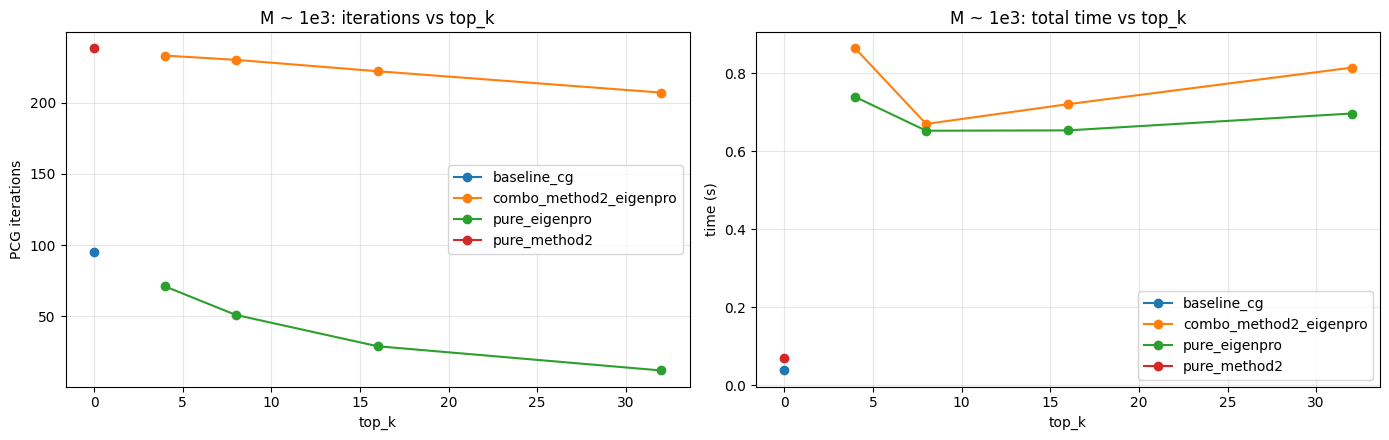

,variant,top_k,N,M,eps,iters,relres,time_eig,time_solve,time_total,n_matvec,scaled,cond_dense,lambda_top,lambda_kplus1,mu,eig_method_used
0,baseline_cg,0,4096,937,3.000000e-07,95,8.190529e-09,0.000000,0.038189,0.038189,96,False,9178.417468,NaN,NaN,NaN,NaN
1,pure_method2,0,4096,937,3.000000e-07,238,7.020601e-09,0.000000,0.069014,0.069014,239,True,10096.414035,NaN,NaN,NaN,NaN
2,pure_eigenpro,8,4096,937,3.000000e-07,51,8.416254e-09,0.629457,0.023566,0.653023,52,False,9178.417468,917.841747,93.411888,93.411888,dense_eigh
3,pure_eigenpro,16,4096,937,3.000000e-07,29,9.424800e-09,0.639220,0.014676,0.653895,30,False,9178.417468,917.841747,10.813179,10.813179,dense_eigh
4,combo_method2_eigenpro,8,4096,937,3.000000e-07,230,8.207742e-09,0.572699,0.097651,0.670350,231,True,10096.414035,2.398750,2.215770,2.215770,dense_eigh
5,pure_eigenpro,32,4096,937,3.000000e-07,12,8.720488e-09,0.691170,0.006002,0.697172,13,False,9178.417468,917.841747,0.900118,0.900118,dense_eigh
6,combo_method2_eigenpro,16,4096,937,3.000000e-07,222,9.804751e-09,0.622505,0.098648,0.721153,223,True,10096.414035,2.398750,2.079654,2.079654,dense_eigh
7,pure_eigenpro,4,4096,937,3.000000e-07,71,9.558232e-09,0.718705,0.020946,0.739651,72,False,9178.417468,917.841747,349.012687,349.012687,dense_eigh
8,combo_method2_eigenpro,32,4096,937,3.000000e-07,207,8.916643e-09,0.712316,0.102431,0.814747,208,True,10096.414035,2.398750,1.850495,1.850495,dense_eigh
9,combo_method2_eigenpro,4,4096,937,3.000000e-07,233,8.346510e-09,0.791899,0.072148,0.864047,234,True,10096.414035,2.398750,2.298427,2.298427,dense_eigh


In [230]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for variant, grp in combo_medium_df.groupby("variant"):
    grp = grp.sort_values("top_k")
    axes[0].plot(grp["top_k"], grp["iters"], marker="o", label=variant)
    axes[1].plot(grp["top_k"], grp["time_total"], marker="o", label=variant)

axes[0].set_title("M ~ 1e3: iterations vs top_k")
axes[0].set_xlabel("top_k")
axes[0].set_ylabel("PCG iterations")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("M ~ 1e3: total time vs top_k")
axes[1].set_xlabel("top_k")
axes[1].set_ylabel("time (s)")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()

combo_medium_best = combo_medium_df.sort_values("time_total").reset_index(drop=True)
combo_medium_best.head(10)


In [231]:
combo_large_df = benchmark_combo_family(
    eps=COMBO_EPS_LARGE,
    n_samples=COMBO_N_LARGE,
    topk_list=[2, 4, 8],
    dense_metrics=False,
    seed=321,
)

combo_large_df = combo_large_df[
    [
        "variant",
        "top_k",
        "N",
        "M",
        "eps",
        "iters",
        "relres",
        "time_eig",
        "time_solve",
        "time_total",
        "n_matvec",
        "scaled",
        "lambda_top",
        "lambda_kplus1",
        "mu",
        "eig_method_used",
    ]
]
combo_large_df.sort_values(["variant", "top_k"]).reset_index(drop=True)


,variant,top_k,N,M,eps,iters,relres,time_eig,time_solve,time_total,n_matvec,scaled,lambda_top,lambda_kplus1,mu,eig_method_used
0,baseline_cg,0,8192,11617,1.000000e-10,121,6.653171e-09,0.000000,0.412842,0.412842,122,False,NaN,NaN,NaN,NaN
1,combo_method2_eigenpro,2,8192,11617,1.000000e-10,409,9.126738e-09,0.235493,1.458258,1.693752,410,True,3.065180,2.878016,2.878016,eigsh
2,combo_method2_eigenpro,4,8192,11617,1.000000e-10,406,9.547863e-09,0.257611,1.436686,1.694297,407,True,3.065180,2.848682,2.848682,eigsh
3,combo_method2_eigenpro,8,8192,11617,1.000000e-10,407,9.736265e-09,0.717137,1.716403,2.433540,408,True,3.020289,2.678636,2.678636,subspace_iter
4,pure_eigenpro,2,8192,11617,1.000000e-10,99,8.829521e-09,0.085086,0.350413,0.435499,100,False,1813.696465,1263.381182,1263.381182,eigsh
5,pure_eigenpro,4,8192,11617,1.000000e-10,84,9.726120e-09,0.073852,0.297023,0.370875,85,False,1813.696465,699.046702,699.046702,eigsh
6,pure_eigenpro,8,8192,11617,1.000000e-10,64,4.973577e-09,0.073626,0.228836,0.302462,65,False,1813.696465,186.089630,186.089630,eigsh
7,pure_method2,0,8192,11617,1.000000e-10,413,9.132792e-09,0.000000,1.416900,1.416900,414,True,NaN,NaN,NaN,NaN


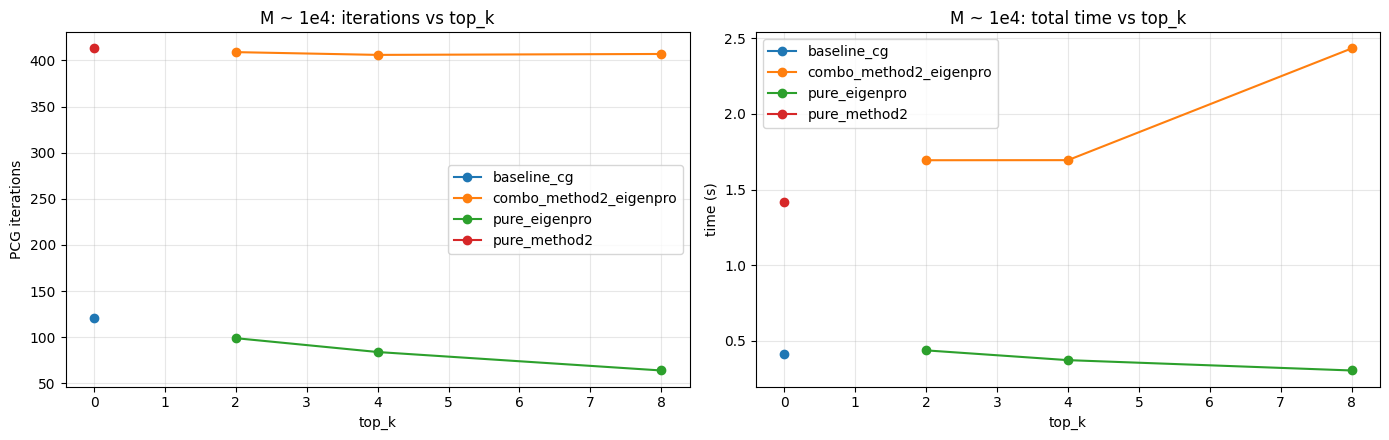

,variant,top_k,N,M,eps,iters,relres,time_eig,time_solve,time_total,n_matvec,scaled,lambda_top,lambda_kplus1,mu,eig_method_used
0,pure_eigenpro,8,8192,11617,1.000000e-10,64,4.973577e-09,0.073626,0.228836,0.302462,65,False,1813.696465,186.089630,186.089630,eigsh
1,pure_eigenpro,4,8192,11617,1.000000e-10,84,9.726120e-09,0.073852,0.297023,0.370875,85,False,1813.696465,699.046702,699.046702,eigsh
2,baseline_cg,0,8192,11617,1.000000e-10,121,6.653171e-09,0.000000,0.412842,0.412842,122,False,NaN,NaN,NaN,NaN
3,pure_eigenpro,2,8192,11617,1.000000e-10,99,8.829521e-09,0.085086,0.350413,0.435499,100,False,1813.696465,1263.381182,1263.381182,eigsh
4,pure_method2,0,8192,11617,1.000000e-10,413,9.132792e-09,0.000000,1.416900,1.416900,414,True,NaN,NaN,NaN,NaN
5,combo_method2_eigenpro,2,8192,11617,1.000000e-10,409,9.126738e-09,0.235493,1.458258,1.693752,410,True,3.065180,2.878016,2.878016,eigsh
6,combo_method2_eigenpro,4,8192,11617,1.000000e-10,406,9.547863e-09,0.257611,1.436686,1.694297,407,True,3.065180,2.848682,2.848682,eigsh
7,combo_method2_eigenpro,8,8192,11617,1.000000e-10,407,9.736265e-09,0.717137,1.716403,2.433540,408,True,3.020289,2.678636,2.678636,subspace_iter


In [232]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for variant, grp in combo_large_df.groupby("variant"):
    grp = grp.sort_values("top_k")
    axes[0].plot(grp["top_k"], grp["iters"], marker="o", label=variant)
    axes[1].plot(grp["top_k"], grp["time_total"], marker="o", label=variant)

axes[0].set_title("M ~ 1e4: iterations vs top_k")
axes[0].set_xlabel("top_k")
axes[0].set_ylabel("PCG iterations")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("M ~ 1e4: total time vs top_k")
axes[1].set_xlabel("top_k")
axes[1].set_ylabel("time (s)")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()

combo_large_df.sort_values("time_total").reset_index(drop=True)


## Structured Benchmark Protocol

This section rebuilds the medium-scale experiment around a unified metric:

- every method is judged by the original system residual
  `||A x - b|| / ||b||`,
  even if it solves a transformed or scaled system;
- setup time, solve time, total time, matvec counts, preconditioner counts,
  and prediction RMSE are reported together;
- explicit dense matrices are used for `M ~ 10^3`, so comparisons are exact and stable.

We benchmark:

- original `A = D G D + lambda I`
- original + Jacobi
- Method 2 scaled system `P2 A P2`
- pure EigenPro on `A`
- combo `Method 2 + EigenPro`
- transformed system `B = G + lambda D^{-2}`
- transformed system + Jacobi
- D-aware active truncation
- low-frequency exact block preconditioner


In [233]:
from scipy.linalg import solve_triangular

STRUCT_KERNEL = COMBO_KERNEL
STRUCT_REG_LAMBDA = COMBO_REG_LAMBDA
STRUCT_NUFFT_TOL = COMBO_NUFFT_TOL
STRUCT_L2_SCALED = COMBO_L2_SCALED
STRUCT_EPS = COMBO_EPS_MEDIUM
STRUCT_N = COMBO_N_MEDIUM
STRUCT_TOPK = 8
STRUCT_BLOCK_SIZE = 128
STRUCT_SOLVE_TOL = 1e-8
STRUCT_MAXITER = 4000
STRUCT_ACTIVE_TAUS = [1e-1, 1e-2, 1e-3, 1e-4]
STRUCT_DINV_FLOOR = 1e-14
STRUCT_TEST_GRID = 2000


def build_medium_dense_problem(eps=STRUCT_EPS, n_samples=STRUCT_N, seed=123):
    x, y = make_dataset(1, n_samples, true_func_1d, noise=0.02, seed=seed)
    solver = EFGPSolver(
        STRUCT_KERNEL,
        reg_lambda=STRUCT_REG_LAMBDA,
        eps=eps,
        nufft_tol=STRUCT_NUFFT_TOL,
        l2scaled=STRUCT_L2_SCALED,
    )
    state = solver.precompute(x, y)
    G, H, A, D = dense_from_state(x, state, solver)
    hm = (state.grid.mtot - 1) // 2
    J = generate_multi_index(hm, solver.kernel.dim)
    tphx = solver._scale_from_center(x, state.x_center, state.grid.h)
    F = np.exp(1j * (tphx @ J.T))
    x_test = np.linspace(0.0, 1.0, STRUCT_TEST_GRID, dtype=np.float64)[:, None]
    y_test = np.asarray(true_func_1d(x_test), dtype=np.float64).reshape(-1)
    tphx_test = solver._scale_from_center(x_test, state.x_center, state.grid.h)
    F_test = np.exp(1j * (tphx_test @ J.T))
    b = np.asarray(state.rhs, dtype=np.complex128)
    return {
        "x": x,
        "y": y,
        "x_test": x_test,
        "y_test": y_test,
        "solver": solver,
        "state": state,
        "F": F,
        "F_test": F_test,
        "J": J,
        "D": np.asarray(D, dtype=np.float64),
        "G": np.asarray(G, dtype=np.complex128),
        "H": np.asarray(H, dtype=np.complex128),
        "A": np.asarray(A, dtype=np.complex128),
        "b": b,
    }


def original_relres_dense(A, x, b):
    r = np.asarray(b, dtype=np.complex128) - np.asarray(A, dtype=np.complex128) @ np.asarray(x, dtype=np.complex128)
    return float(np.linalg.norm(r) / max(np.linalg.norm(b), 1e-30))


def predict_from_beta(F, D, beta):
    Phi = np.asarray(F, dtype=np.complex128) * np.asarray(D, dtype=np.float64)[None, :]
    return np.real(Phi @ np.asarray(beta, dtype=np.complex128))


def rmse_from_beta(F, D, beta, y):
    yhat = predict_from_beta(F, D, beta)
    return float(np.sqrt(np.mean((yhat - np.asarray(y, dtype=np.float64)) ** 2)))


def objective_from_beta(F, D, beta, y, reg_lambda=STRUCT_REG_LAMBDA):
    resid = predict_from_beta(F, D, beta) - np.asarray(y, dtype=np.float64)
    beta = np.asarray(beta, dtype=np.complex128)
    return float(0.5 * np.vdot(resid, resid).real + 0.5 * reg_lambda * np.vdot(beta, beta).real)


def objective_gap(value, reference, eps=1e-30):
    return float((value - reference) / max(abs(reference), eps))


def summarize_beta_metrics(
    F_train,
    D,
    beta,
    y_train,
    F_test,
    y_test,
    *,
    reg_lambda=STRUCT_REG_LAMBDA,
    objective_ref=None,
):
    train_rmse = rmse_from_beta(F_train, D, beta, y_train)
    test_rmse = rmse_from_beta(F_test, D, beta, y_test)
    objective = objective_from_beta(F_train, D, beta, y_train, reg_lambda=reg_lambda)
    out = {
        "rmse_train": float(train_rmse),
        "rmse_test": float(test_rmse),
        "objective": float(objective),
    }
    if objective_ref is not None:
        out["objective_gap"] = objective_gap(objective, objective_ref)
    return out


def run_pcg_dense(A, b, *, precond=None, tol=STRUCT_SOLVE_TOL, maxiter=STRUCT_MAXITER, recover=None, A_orig=None, b_orig=None):
    A = np.asarray(A, dtype=np.complex128)
    b = np.asarray(b, dtype=np.complex128)

    def matvec(v):
        return A @ np.asarray(v, dtype=np.complex128)

    t0 = time.perf_counter()
    z, it, relres_trans, _hist, stats = pcg_solve(
        matvec,
        b,
        tol=tol,
        maxiter=maxiter,
        precond=precond,
        store_history=False,
        return_stats=True,
    )
    t1 = time.perf_counter()
    x = recover(z) if recover is not None else z
    relres_orig = original_relres_dense(A_orig if A_orig is not None else A, x, b_orig if b_orig is not None else b)
    return {
        "z": z,
        "x": x,
        "iters": int(it),
        "relres_trans": float(relres_trans),
        "relres_orig": float(relres_orig),
        "time_solve": float(t1 - t0),
        "n_matvec": int(stats["n_matvec"]),
        "n_precond": int(stats["n_precond"]),
        "t_matvec_total": float(stats["t_matvec_total"]),
        "t_precond_total": float(stats["t_precond_total"]),
    }


def jacobi_precond_from_diag(diag):
    diag = np.asarray(diag, dtype=np.complex128)
    inv = 1.0 / np.where(np.abs(diag) > 0, diag, 1.0)

    def pre(v):
        return inv * np.asarray(v, dtype=np.complex128)

    return pre


def compute_rho(N, D, reg_lambda=STRUCT_REG_LAMBDA):
    D = np.asarray(D, dtype=np.float64)
    return (N * (np.abs(D) ** 2)) / float(reg_lambda)


def active_set_from_tau(rho, tau):
    rho = np.asarray(rho, dtype=np.float64)
    return np.where(rho >= float(tau))[0]


def tail_energy(N, D, keep_idx):
    all_idx = np.arange(D.size)
    mask = np.ones(D.size, dtype=bool)
    mask[np.asarray(keep_idx, dtype=int)] = False
    return float(N * np.sum(np.abs(np.asarray(D)[mask]) ** 2))


def transformed_system_B(G, D, reg_lambda=STRUCT_REG_LAMBDA, floor=STRUCT_DINV_FLOOR):
    D = np.asarray(D, dtype=np.float64)
    d_safe = np.maximum(np.abs(D), float(floor))
    return hermitian_part(np.asarray(G, dtype=np.complex128) + reg_lambda * np.diag(1.0 / (d_safe ** 2)))


def low_frequency_block_precond(A, S):
    A = np.asarray(A, dtype=np.complex128)
    S = np.asarray(S, dtype=int)
    all_idx = np.arange(A.shape[0])
    mask = np.ones(A.shape[0], dtype=bool)
    mask[S] = False
    T = all_idx[mask]
    A_SS = hermitian_part(A[np.ix_(S, S)])
    L = np.linalg.cholesky(A_SS)
    diag_T = np.diag(A)[T]
    diag_inv_T = 1.0 / np.where(np.abs(diag_T) > 0, diag_T, 1.0)

    def pre(v):
        v = np.asarray(v, dtype=np.complex128)
        out = np.zeros_like(v)
        rhs_S = v[S]
        y = solve_triangular(L, rhs_S, lower=True, check_finite=False)
        out[S] = solve_triangular(L.conj().T, y, lower=False, check_finite=False)
        out[T] = diag_inv_T * v[T]
        return out

    return pre, A_SS.shape[0], T.size


def solve_active_truncation(
    A,
    b,
    F_train,
    D,
    y_train,
    F_test,
    y_test,
    tau,
    N,
    *,
    reg_lambda=STRUCT_REG_LAMBDA,
    objective_ref=None,
):
    rho = compute_rho(N, D, reg_lambda=reg_lambda)
    S = active_set_from_tau(rho, tau)
    if S.size == 0:
        return None
    t0 = time.perf_counter()
    A_S = hermitian_part(np.asarray(A)[np.ix_(S, S)])
    b_S = np.asarray(b)[S]
    x_S = np.linalg.solve(A_S, b_S)
    t1 = time.perf_counter()
    x_full = np.zeros(A.shape[0], dtype=np.complex128)
    x_full[S] = x_S
    metrics = summarize_beta_metrics(
        F_train,
        D,
        x_full,
        y_train,
        F_test,
        y_test,
        reg_lambda=reg_lambda,
        objective_ref=objective_ref,
    )
    return {
        "tau": float(tau),
        "S": S,
        "size_S": int(S.size),
        "tail_energy": tail_energy(N, D, S),
        "beta": x_full,
        "relres_orig": original_relres_dense(A, x_full, b),
        "solve_time": float(t1 - t0),
        "total_time": float(t1 - t0),
        **metrics,
    }


def solve_active_block_pcg(
    A,
    b,
    F_train,
    D,
    y_train,
    F_test,
    y_test,
    tau,
    N,
    *,
    reg_lambda=STRUCT_REG_LAMBDA,
    tol=STRUCT_SOLVE_TOL,
    maxiter=STRUCT_MAXITER,
    objective_ref=None,
):
    rho = compute_rho(N, D, reg_lambda=reg_lambda)
    S = active_set_from_tau(rho, tau)
    if S.size == 0:
        return None
    t0 = time.perf_counter()
    pre_block, size_S, size_T = low_frequency_block_precond(A, S)
    t1 = time.perf_counter()
    out = run_pcg_dense(A, b, precond=pre_block, A_orig=A, b_orig=b, tol=tol, maxiter=maxiter)
    metrics = summarize_beta_metrics(
        F_train,
        D,
        out["x"],
        y_train,
        F_test,
        y_test,
        reg_lambda=reg_lambda,
        objective_ref=objective_ref,
    )
    return {
        "tau": float(tau),
        "S": S,
        "size_S": int(size_S),
        "size_T": int(size_T),
        "tail_energy": tail_energy(N, D, S),
        "beta": out["x"],
        "setup_time": float(t1 - t0),
        "solve_time": float(out["time_solve"]),
        "total_time": float((t1 - t0) + out["time_solve"]),
        "iters": int(out["iters"]),
        "n_matvec": int(out["n_matvec"]),
        "n_precond": int(out["n_precond"]),
        "t_matvec_total": float(out["t_matvec_total"]),
        "t_precond_total": float(out["t_precond_total"]),
        "avg_matvec_time": float(out["t_matvec_total"] / max(out["n_matvec"], 1)),
        "avg_precond_time": float(out["t_precond_total"] / max(out["n_precond"], 1)),
        "relres_trans": float(out["relres_trans"]),
        "relres_orig": float(out["relres_orig"]),
        **metrics,
    }


In [234]:
medium = build_medium_dense_problem()
A = medium["A"]
G = medium["G"]
D = medium["D"]
F = medium["F"]
F_test = medium["F_test"]
b = medium["b"]
y = medium["y"]
y_test = medium["y_test"]
N = medium["x"].shape[0]
M = A.shape[0]

full_beta = np.linalg.solve(A, b)
full_metrics = summarize_beta_metrics(
    F,
    D,
    full_beta,
    y,
    F_test,
    y_test,
    reg_lambda=STRUCT_REG_LAMBDA,
    objective_ref=None,
)
full_objective = full_metrics["objective"]

rho = compute_rho(N, D, reg_lambda=STRUCT_REG_LAMBDA)
p2 = 1.0 / np.sqrt(N * (np.abs(D) ** 2) + STRUCT_REG_LAMBDA)
A_tilde = hermitian_part((p2[:, None] * A) * p2[None, :])
b_tilde = p2.astype(np.complex128) * b
B = transformed_system_B(G, D, reg_lambda=STRUCT_REG_LAMBDA)
rhs_B = np.asarray(F.conj().T @ y, dtype=np.complex128)

bench_rows = []

# Baseline on A.
out = run_pcg_dense(A, b, A_orig=A, b_orig=b)
metrics = summarize_beta_metrics(F, D, out["x"], y, F_test, y_test, reg_lambda=STRUCT_REG_LAMBDA, objective_ref=full_objective)
bench_rows.append({
    "method": "baseline_cg",
    "setup_time": 0.0,
    "solve_time": out["time_solve"],
    "total_time": out["time_solve"],
    "iters": out["iters"],
    "n_matvec": out["n_matvec"],
    "n_precond": out["n_precond"],
    "t_matvec_total": out["t_matvec_total"],
    "t_precond_total": out["t_precond_total"],
    "avg_matvec_time": out["t_matvec_total"] / max(out["n_matvec"], 1),
    "avg_precond_time": out["t_precond_total"] / max(out["n_precond"], 1),
    "final_original_relres": out["relres_orig"],
    "final_transformed_relres": out["relres_trans"],
    "system": "A",
    **metrics,
})

# Jacobi on A.
pre_A = jacobi_precond_from_diag(np.diag(A))
out = run_pcg_dense(A, b, precond=pre_A, A_orig=A, b_orig=b)
metrics = summarize_beta_metrics(F, D, out["x"], y, F_test, y_test, reg_lambda=STRUCT_REG_LAMBDA, objective_ref=full_objective)
bench_rows.append({
    "method": "jacobi_on_A",
    "setup_time": 0.0,
    "solve_time": out["time_solve"],
    "total_time": out["time_solve"],
    "iters": out["iters"],
    "n_matvec": out["n_matvec"],
    "n_precond": out["n_precond"],
    "t_matvec_total": out["t_matvec_total"],
    "t_precond_total": out["t_precond_total"],
    "avg_matvec_time": out["t_matvec_total"] / max(out["n_matvec"], 1),
    "avg_precond_time": out["t_precond_total"] / max(out["n_precond"], 1),
    "final_original_relres": out["relres_orig"],
    "final_transformed_relres": out["relres_trans"],
    "system": "A",
    **metrics,
})

# Method 2 scaled system.
out = run_pcg_dense(
    A_tilde,
    b_tilde,
    A_orig=A,
    b_orig=b,
    recover=lambda z: p2.astype(np.complex128) * z,
)
metrics = summarize_beta_metrics(F, D, out["x"], y, F_test, y_test, reg_lambda=STRUCT_REG_LAMBDA, objective_ref=full_objective)
bench_rows.append({
    "method": "method2_scaled_only",
    "setup_time": 0.0,
    "solve_time": out["time_solve"],
    "total_time": out["time_solve"],
    "iters": out["iters"],
    "n_matvec": out["n_matvec"],
    "n_precond": out["n_precond"],
    "t_matvec_total": out["t_matvec_total"],
    "t_precond_total": out["t_precond_total"],
    "avg_matvec_time": out["t_matvec_total"] / max(out["n_matvec"], 1),
    "avg_precond_time": out["t_precond_total"] / max(out["n_precond"], 1),
    "final_original_relres": out["relres_orig"],
    "final_transformed_relres": out["relres_trans"],
    "system": "P2 A P2",
    **metrics,
})

# Pure EigenPro on A.
t0 = time.perf_counter()
eig_A, pre_A_ep, mu_A, tag_A = eigenpro_from_dense_matrix(A, STRUCT_TOPK)
t1 = time.perf_counter()
out = run_pcg_dense(A, b, precond=pre_A_ep.apply, A_orig=A, b_orig=b)
metrics = summarize_beta_metrics(F, D, out["x"], y, F_test, y_test, reg_lambda=STRUCT_REG_LAMBDA, objective_ref=full_objective)
bench_rows.append({
    "method": "pure_eigenpro_on_A",
    "setup_time": float(t1 - t0),
    "solve_time": out["time_solve"],
    "total_time": float((t1 - t0) + out["time_solve"]),
    "iters": out["iters"],
    "n_matvec": out["n_matvec"],
    "n_precond": out["n_precond"],
    "t_matvec_total": out["t_matvec_total"],
    "t_precond_total": out["t_precond_total"],
    "avg_matvec_time": out["t_matvec_total"] / max(out["n_matvec"], 1),
    "avg_precond_time": out["t_precond_total"] / max(out["n_precond"], 1),
    "final_original_relres": out["relres_orig"],
    "final_transformed_relres": out["relres_trans"],
    "system": "A",
    "mu": mu_A,
    "eig_method": tag_A,
    **metrics,
})

# Combo Method 2 + EigenPro.
t0 = time.perf_counter()
eig_T, pre_T_ep, mu_T, tag_T = eigenpro_from_dense_matrix(A_tilde, STRUCT_TOPK)
t1 = time.perf_counter()
out = run_pcg_dense(
    A_tilde,
    b_tilde,
    precond=pre_T_ep.apply,
    A_orig=A,
    b_orig=b,
    recover=lambda z: p2.astype(np.complex128) * z,
)
metrics = summarize_beta_metrics(F, D, out["x"], y, F_test, y_test, reg_lambda=STRUCT_REG_LAMBDA, objective_ref=full_objective)
bench_rows.append({
    "method": "combo_method2_eigenpro",
    "setup_time": float(t1 - t0),
    "solve_time": out["time_solve"],
    "total_time": float((t1 - t0) + out["time_solve"]),
    "iters": out["iters"],
    "n_matvec": out["n_matvec"],
    "n_precond": out["n_precond"],
    "t_matvec_total": out["t_matvec_total"],
    "t_precond_total": out["t_precond_total"],
    "avg_matvec_time": out["t_matvec_total"] / max(out["n_matvec"], 1),
    "avg_precond_time": out["t_precond_total"] / max(out["n_precond"], 1),
    "final_original_relres": out["relres_orig"],
    "final_transformed_relres": out["relres_trans"],
    "system": "P2 A P2",
    "mu": mu_T,
    "eig_method": tag_T,
    **metrics,
})

# Variable-transform system B.
out_B = run_pcg_dense(
    B,
    rhs_B,
    A_orig=A,
    b_orig=b,
    recover=lambda u: np.where(np.abs(D) > STRUCT_DINV_FLOOR, u / D, 0.0),
)
metrics = summarize_beta_metrics(F, D, out_B["x"], y, F_test, y_test, reg_lambda=STRUCT_REG_LAMBDA, objective_ref=full_objective)
bench_rows.append({
    "method": "variable_transform_B",
    "setup_time": 0.0,
    "solve_time": out_B["time_solve"],
    "total_time": out_B["time_solve"],
    "iters": out_B["iters"],
    "n_matvec": out_B["n_matvec"],
    "n_precond": out_B["n_precond"],
    "t_matvec_total": out_B["t_matvec_total"],
    "t_precond_total": out_B["t_precond_total"],
    "avg_matvec_time": out_B["t_matvec_total"] / max(out_B["n_matvec"], 1),
    "avg_precond_time": out_B["t_precond_total"] / max(out_B["n_precond"], 1),
    "final_original_relres": out_B["relres_orig"],
    "final_transformed_relres": out_B["relres_trans"],
    "system": "B = G + lambda D^{-2}",
    **metrics,
})

# Variable-transform + Jacobi.
pre_B = jacobi_precond_from_diag(np.diag(B))
out_Bj = run_pcg_dense(
    B,
    rhs_B,
    precond=pre_B,
    A_orig=A,
    b_orig=b,
    recover=lambda u: np.where(np.abs(D) > STRUCT_DINV_FLOOR, u / D, 0.0),
)
metrics = summarize_beta_metrics(F, D, out_Bj["x"], y, F_test, y_test, reg_lambda=STRUCT_REG_LAMBDA, objective_ref=full_objective)
bench_rows.append({
    "method": "jacobi_on_B",
    "setup_time": 0.0,
    "solve_time": out_Bj["time_solve"],
    "total_time": out_Bj["time_solve"],
    "iters": out_Bj["iters"],
    "n_matvec": out_Bj["n_matvec"],
    "n_precond": out_Bj["n_precond"],
    "t_matvec_total": out_Bj["t_matvec_total"],
    "t_precond_total": out_Bj["t_precond_total"],
    "avg_matvec_time": out_Bj["t_matvec_total"] / max(out_Bj["n_matvec"], 1),
    "avg_precond_time": out_Bj["t_precond_total"] / max(out_Bj["n_precond"], 1),
    "final_original_relres": out_Bj["relres_orig"],
    "final_transformed_relres": out_Bj["relres_trans"],
    "system": "B = G + lambda D^{-2}",
    **metrics,
})

# Low-frequency exact block preconditioner based on rho-threshold tau=1e-2.
block_tau = 1e-2
block_res = solve_active_block_pcg(
    A,
    b,
    F,
    D,
    y,
    F_test,
    y_test,
    block_tau,
    N,
    reg_lambda=STRUCT_REG_LAMBDA,
    tol=STRUCT_SOLVE_TOL,
    maxiter=STRUCT_MAXITER,
    objective_ref=full_objective,
)
bench_rows.append({
    "method": f"active_block_precond_tau_{block_tau:g}",
    "setup_time": float(block_res["setup_time"]),
    "solve_time": float(block_res["solve_time"]),
    "total_time": float(block_res["total_time"]),
    "iters": int(block_res["iters"]),
    "n_matvec": int(block_res["n_matvec"]),
    "n_precond": int(block_res["n_precond"]),
    "t_matvec_total": float(block_res["t_matvec_total"]),
    "t_precond_total": float(block_res["t_precond_total"]),
    "avg_matvec_time": float(block_res["avg_matvec_time"]),
    "avg_precond_time": float(block_res["avg_precond_time"]),
    "final_original_relres": float(block_res["relres_orig"]),
    "final_transformed_relres": float(block_res["relres_trans"]),
    "rmse_train": float(block_res["rmse_train"]),
    "rmse_test": float(block_res["rmse_test"]),
    "objective": float(block_res["objective"]),
    "objective_gap": float(block_res["objective_gap"]),
    "system": "A",
    "active_block_size": int(block_res["size_S"]),
    "tail_size": int(block_res["size_T"]),
})

structured_bench_df = pd.DataFrame(bench_rows)
structured_bench_df.sort_values("total_time").reset_index(drop=True)


,method,setup_time,solve_time,total_time,iters,n_matvec,n_precond,t_matvec_total,t_precond_total,avg_matvec_time,avg_precond_time,final_original_relres,final_transformed_relres,system,rmse_train,rmse_test,objective,objective_gap,mu,eig_method,active_block_size,tail_size
0,active_block_precond_tau_0.01,0.008794,0.008929,0.017723,5,6,5,0.003527,0.004906,0.000588,0.000981,2.267515e-10,2.267515e-10,A,0.019679,0.001960,0.990119,2.466865e-15,NaN,NaN,301.0,636.0
1,baseline_cg,0.000000,0.018451,0.018451,98,99,0,0.014872,0.000000,0.000150,0.000000,5.685658e-09,5.685658e-09,A,0.019679,0.001960,0.990119,4.134859e-11,NaN,NaN,NaN,NaN
2,jacobi_on_A,0.000000,0.037750,0.037750,211,212,211,0.029635,0.000604,0.000140,0.000003,9.574518e-09,9.574518e-09,A,0.019679,0.001960,0.990119,3.266944e-10,NaN,NaN,NaN,NaN
3,jacobi_on_B,0.000000,0.044137,0.044137,238,239,238,0.034489,0.000702,0.000144,0.000003,9.704317e-10,7.102787e-09,B = G + lambda D^{-2},0.019679,0.001960,0.990119,1.225584e-13,NaN,NaN,NaN,NaN
4,method2_scaled_only,0.000000,0.044545,0.044545,235,236,0,0.035296,0.000000,0.000150,0.000000,1.638131e-09,9.422514e-09,P2 A P2,0.019679,0.001960,0.990119,1.030253e-12,NaN,NaN,NaN,NaN
5,combo_method2_eigenpro,0.547742,0.069056,0.616798,227,228,227,0.035769,0.024310,0.000157,0.000107,1.171478e-09,7.706642e-09,P2 A P2,0.019679,0.001960,0.990119,5.055953e-13,2.215770,dense_eigh,NaN,NaN
6,pure_eigenpro_on_A,0.620477,0.017164,0.637641,50,51,50,0.009249,0.005597,0.000181,0.000112,9.066144e-09,9.066144e-09,A,0.019679,0.001960,0.990119,1.371453e-10,93.411888,dense_eigh,NaN,NaN
7,variable_transform_B,0.000000,0.701454,0.701454,4000,4001,0,0.556741,0.000000,0.000139,0.000000,1.401013e-05,1.025984e-03,B = G + lambda D^{-2},0.019680,0.001968,0.990728,6.150302e-04,NaN,NaN,NaN,NaN


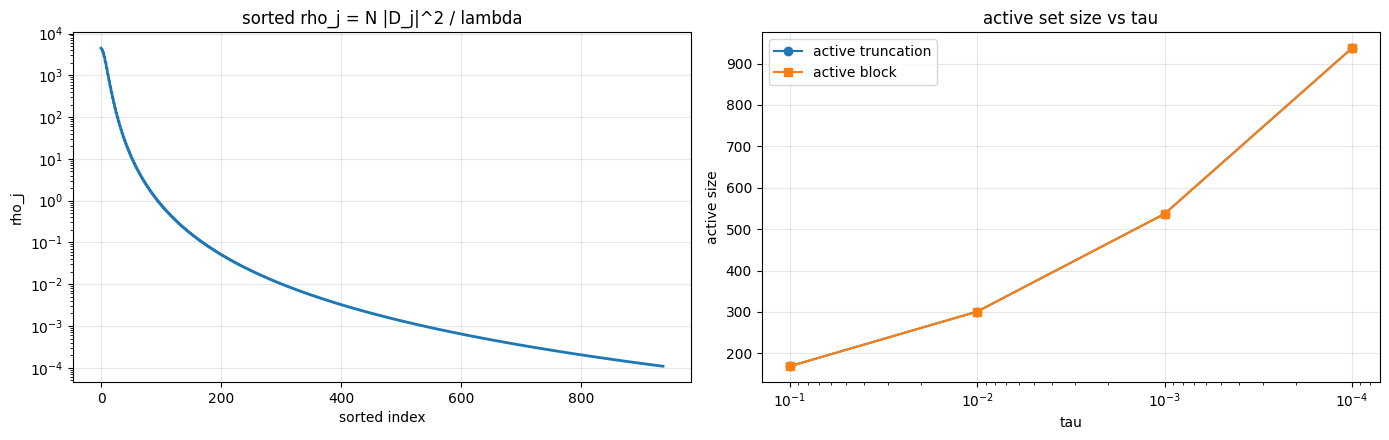

(      tau  |S_tau|  tail_energy  final_original_relres  train_rmse  test_rmse  \
 0  0.1000      169     0.569382           1.244335e-05    0.019706   0.001953   
 1  0.0100      301     0.098400           4.837610e-06    0.019684   0.001960   
 2  0.0010      537     0.014567           2.080625e-06    0.019680   0.001960   
 3  0.0001      937     0.000000           2.834169e-15    0.019679   0.001960   
 
    objective  objective_gap  beta_relerr_vs_full  solve_time  total_time  
 0   0.991243       0.001135             0.072604    0.165637    0.165637  
 1   0.990302       0.000185             0.030352    0.014818    0.014818  
 2   0.990153       0.000034             0.013155    0.033365    0.033365  
 3   0.990119       0.000000             0.000000    0.056114    0.056114  ,
       tau  |S|  |T|  tail_energy  setup_time  solve_time  total_time  iters  \
 0  0.1000  169  768     0.569382    0.002037    0.003827    0.005864      7   
 1  0.0100  301  636     0.098400    0.006317  

In [235]:
rho_sorted = np.sort(rho)[::-1]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].semilogy(rho_sorted, lw=2)
axes[0].set_title("sorted rho_j = N |D_j|^2 / lambda")
axes[0].set_xlabel("sorted index")
axes[0].set_ylabel("rho_j")
axes[0].grid(alpha=0.3)

active_rows = []
block_rows = []
for tau in STRUCT_ACTIVE_TAUS:
    trunc_res = solve_active_truncation(
        A,
        b,
        F,
        D,
        y,
        F_test,
        y_test,
        tau,
        N,
        reg_lambda=STRUCT_REG_LAMBDA,
        objective_ref=full_objective,
    )
    if trunc_res is not None:
        beta_err = float(np.linalg.norm(trunc_res["beta"] - full_beta) / max(np.linalg.norm(full_beta), 1e-30))
        active_rows.append({
            "tau": float(tau),
            "|S_tau|": int(trunc_res["size_S"]),
            "tail_energy": float(trunc_res["tail_energy"]),
            "final_original_relres": float(trunc_res["relres_orig"]),
            "train_rmse": float(trunc_res["rmse_train"]),
            "test_rmse": float(trunc_res["rmse_test"]),
            "objective": float(trunc_res["objective"]),
            "objective_gap": float(trunc_res["objective_gap"]),
            "beta_relerr_vs_full": beta_err,
            "solve_time": float(trunc_res["solve_time"]),
            "total_time": float(trunc_res["total_time"]),
        })

    block_res = solve_active_block_pcg(
        A,
        b,
        F,
        D,
        y,
        F_test,
        y_test,
        tau,
        N,
        reg_lambda=STRUCT_REG_LAMBDA,
        tol=STRUCT_SOLVE_TOL,
        maxiter=STRUCT_MAXITER,
        objective_ref=full_objective,
    )
    if block_res is not None:
        block_rows.append({
            "tau": float(tau),
            "|S|": int(block_res["size_S"]),
            "|T|": int(block_res["size_T"]),
            "tail_energy": float(block_res["tail_energy"]),
            "setup_time": float(block_res["setup_time"]),
            "solve_time": float(block_res["solve_time"]),
            "total_time": float(block_res["total_time"]),
            "iters": int(block_res["iters"]),
            "n_matvec": int(block_res["n_matvec"]),
            "n_precond": int(block_res["n_precond"]),
            "avg_matvec_time": float(block_res["avg_matvec_time"]),
            "avg_precond_time": float(block_res["avg_precond_time"]),
            "final_original_relres": float(block_res["relres_orig"]),
            "final_transformed_relres": float(block_res["relres_trans"]),
            "train_rmse": float(block_res["rmse_train"]),
            "test_rmse": float(block_res["rmse_test"]),
            "objective": float(block_res["objective"]),
            "objective_gap": float(block_res["objective_gap"]),
        })

active_df = pd.DataFrame(active_rows)
block_df = pd.DataFrame(block_rows)
axes[1].plot(active_df["tau"], active_df["|S_tau|"], marker="o", label="active truncation")
axes[1].plot(block_df["tau"], block_df["|S|"], marker="s", label="active block")
axes[1].set_xscale("log")
axes[1].invert_xaxis()
axes[1].set_title("active set size vs tau")
axes[1].set_xlabel("tau")
axes[1].set_ylabel("active size")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()
active_df, block_df


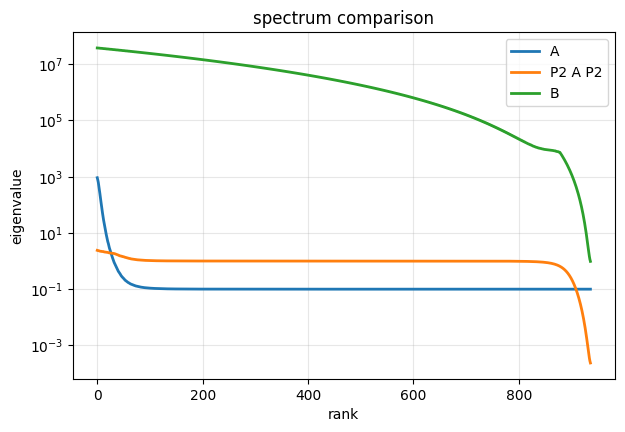

,lambda_1,lambda_5,lambda_10,lambda_50,lambda_median,lambda_min,system
0,9.178417e+02,3.490127e+02,6.866942e+01,2.529403e-01,1.000000e-01,0.100000,A
1,2.398750e+00,2.298427e+00,2.182409e+00,1.437745e+00,9.998568e-01,0.000238,P2 A P2
2,3.770268e+07,3.706241e+07,3.643028e+07,3.054526e+07,2.362496e+06,0.973376,B = G + lambda D^{-2}


In [236]:
def spectral_summary(eigs, name):
    vals = np.sort(np.real(np.asarray(eigs)))[::-1]
    pick = {
        "lambda_1": vals[0],
        "lambda_5": vals[min(4, len(vals) - 1)],
        "lambda_10": vals[min(9, len(vals) - 1)],
        "lambda_50": vals[min(49, len(vals) - 1)],
        "lambda_median": vals[len(vals) // 2],
        "lambda_min": vals[-1],
    }
    pick["system"] = name
    return pick

spec_df = pd.DataFrame([
    spectral_summary(np.linalg.eigvalsh(A), "A"),
    spectral_summary(np.linalg.eigvalsh(A_tilde), "P2 A P2"),
    spectral_summary(np.linalg.eigvalsh(B), "B = G + lambda D^{-2}"),
])

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, vals in [
    ("A", np.linalg.eigvalsh(A)),
    ("P2 A P2", np.linalg.eigvalsh(A_tilde)),
    ("B", np.linalg.eigvalsh(B)),
]:
    s = np.sort(np.real(vals))[::-1]
    ax.semilogy(np.maximum(s, 1e-16), lw=2, label=label)
ax.set_title("spectrum comparison")
ax.set_xlabel("rank")
ax.set_ylabel("eigenvalue")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

spec_df


## Stable Timing And Large Matrix-Free Active Block

This section fills the remaining experimental gaps:

- use repeated timing and report median / IQR, instead of relying on one-shot wall time;
- rename the noiseless test metric more explicitly as `test_true_rmse`;
- add a large-scale `M ~ 10^4` matrix-free active block benchmark,
  where we build only the low-frequency block `A_SS`
  without forming the full dense matrix `A`.

Interpretation reminder:

- `active truncation` is an approximate compressed model;
- `active block preconditioner` still solves the full system `A beta = b`.


In [237]:
import statistics

from scipy.linalg import solve_triangular


TIMING_REPEATS_DENSE = 5
TIMING_REPEATS_LARGE = 3
TIMING_WARMUP = 1
LARGE_ACTIVE_TAUS = [1e-1, 1e-2, 1e-3]
LARGE_FIXED_BLOCK_SIZES = [64, 128, 256, 512, 1024]
LARGE_EIGENPRO_TOPK = [4, 8]
LARGE_SEED = 321


def _real_scalar(x):
    arr = np.asarray(x)
    return float(np.real(arr.reshape(-1)[0]))


def median_iqr(values):
    vals = np.asarray(values, dtype=np.float64)
    if vals.size == 0:
        return np.nan, np.nan
    q1, q3 = np.percentile(vals, [25.0, 75.0])
    return float(np.median(vals)), float(q3 - q1)


def repeat_measure(fn, repeats=TIMING_REPEATS_DENSE, warmup=TIMING_WARMUP):
    for _ in range(max(int(warmup), 0)):
        fn()
    outputs = []
    times = []
    for _ in range(int(repeats)):
        t0 = time.perf_counter()
        out = fn()
        t1 = time.perf_counter()
        outputs.append(out)
        times.append(float(t1 - t0))
    med, iqr = median_iqr(times)
    return {
        "outputs": outputs,
        "times": [float(t) for t in times],
        "time_median": float(med),
        "time_iqr": float(iqr),
        "output_last": outputs[-1],
    }


def rename_test_metric_columns(df):
    df = df.copy()
    return df.rename(columns={"rmse_test": "test_true_rmse"})


def measured_predict_from_beta(F, D, beta):
    t0 = time.perf_counter()
    yhat = predict_from_beta(F, D, beta)
    t1 = time.perf_counter()
    return yhat, float(t1 - t0)


def summarize_beta_metrics_with_timing(
    F_train,
    D,
    beta,
    y_train,
    F_test,
    y_test,
    *,
    reg_lambda=STRUCT_REG_LAMBDA,
    objective_ref=None,
):
    t0 = time.perf_counter()
    train_pred = predict_from_beta(F_train, D, beta)
    t1 = time.perf_counter()
    test_pred = predict_from_beta(F_test, D, beta)
    t2 = time.perf_counter()
    train_rmse = float(np.sqrt(np.mean((train_pred - np.asarray(y_train, dtype=np.float64)) ** 2)))
    test_true_rmse = float(np.sqrt(np.mean((test_pred - np.asarray(y_test, dtype=np.float64)) ** 2)))
    objective = objective_from_beta(F_train, D, beta, y_train, reg_lambda=reg_lambda)
    out = {
        "rmse_train": float(train_rmse),
        "test_true_rmse": float(test_true_rmse),
        "objective": float(objective),
        "time_predict_train": float(t1 - t0),
        "time_predict_test": float(t2 - t1),
        "time_predict_total": float(t2 - t0),
    }
    if objective_ref is not None:
        out["objective_gap"] = objective_gap(objective, objective_ref)
    return out


def summarize_repeat_numeric(outputs, key):
    vals = [_real_scalar(out[key]) for out in outputs if key in out and out[key] is not None]
    if len(vals) == 0:
        return np.nan, np.nan
    return median_iqr(vals)


def attach_repeat_summary(row, measured, time_key):
    row = dict(row)
    row[time_key] = float(measured["time_median"])
    row[f"{time_key}_iqr"] = float(measured["time_iqr"])
    return row


def make_active_indices_from_size(rho, size):
    rho = np.asarray(rho, dtype=np.float64).reshape(-1)
    size = int(min(max(size, 1), rho.size))
    order = np.argsort(rho)[::-1]
    keep = np.sort(order[:size])
    return keep


def build_dense_submatrix_via_matvec(matvec, idx, block_size=64):
    idx = np.asarray(idx, dtype=int)
    m = idx.size
    A_SS = np.zeros((m, m), dtype=np.complex128)
    for start in range(0, m, int(block_size)):
        stop = min(start + int(block_size), m)
        cols = stop - start
        basis = np.zeros((matvec.size, cols), dtype=np.complex128)
        basis[idx[start:stop], np.arange(cols)] = 1.0
        block = np.asarray(matvec.apply_block(basis), dtype=np.complex128)
        A_SS[:, start:stop] = block[idx, :]
    return hermitian_part(A_SS)


def build_A_SS_from_F(F_train, D, S, reg_lambda):
    S = np.asarray(S, dtype=int)
    FS = np.asarray(F_train[:, S], dtype=np.complex128)
    DS = np.asarray(D[S], dtype=np.complex128)
    G_SS = hermitian_part(FS.conj().T @ FS)
    A_SS = (DS[:, None].conj() * G_SS) * DS[None, :]
    A_SS += reg_lambda * np.eye(S.size, dtype=np.complex128)
    return hermitian_part(A_SS)


def build_G_SS_unique_lags_1d(tphx, J, S):
    S = np.asarray(S, dtype=int)
    jS = np.asarray(J[S, 0], dtype=int).reshape(-1)
    x_scaled = np.asarray(tphx[:, 0], dtype=np.float64).reshape(-1)
    # For F_{n,j} = exp(i * t_n * j), we have G_{jk} = sum_n exp(i * t_n * (k - j)).
    lag_mat = jS[None, :] - jS[:, None]
    unique_lags, inv = np.unique(lag_mat.reshape(-1), return_inverse=True)
    phase = np.outer(x_scaled, unique_lags)
    g_unique = np.exp(1j * phase).sum(axis=0)
    G_SS = g_unique[inv].reshape(S.size, S.size)
    return hermitian_part(np.asarray(G_SS, dtype=np.complex128))


def build_A_SS_from_unique_lags_1d(tphx, J, D, S, reg_lambda):
    S = np.asarray(S, dtype=int)
    DS = np.asarray(D[S], dtype=np.complex128)
    G_SS = build_G_SS_unique_lags_1d(tphx, J, S)
    A_SS = (DS[:, None].conj() * G_SS) * DS[None, :]
    A_SS += reg_lambda * np.eye(S.size, dtype=np.complex128)
    return hermitian_part(A_SS)


def compare_A_SS_builds(problem, S, reg_lambda=COMBO_REG_LAMBDA, block_size=STRUCT_BLOCK_SIZE):
    solver = problem["solver"]
    state = problem["state"]
    D = problem["D"]
    F_train = problem["F_train"]
    J = problem["J"]
    tphx = problem["tphx"]
    counted = CountedOperator(solver, state)
    A_basis = build_dense_submatrix_via_matvec(counted, S, block_size=block_size)
    A_gram = build_A_SS_from_F(F_train, D, S, reg_lambda)
    A_lag = build_A_SS_from_unique_lags_1d(tphx, J, D, S, reg_lambda)

    def relerr(A, B):
        denom = max(np.linalg.norm(B), 1e-30)
        return float(np.linalg.norm(A - B) / denom)

    return {
        "basis_vs_gram": relerr(A_basis, A_gram),
        "basis_vs_lag": relerr(A_basis, A_lag),
        "gram_vs_lag": relerr(A_gram, A_lag),
        "basis_matvec_equiv": int(counted.n_matvec),
    }


def diagonal_from_matvec(matvec, size, chunk_size=128):
    diag = np.zeros(int(size), dtype=np.complex128)
    for start in range(0, int(size), int(chunk_size)):
        stop = min(start + int(chunk_size), int(size))
        cols = stop - start
        basis = np.zeros((int(size), cols), dtype=np.complex128)
        basis[start:stop, np.arange(cols)] = 1.0
        block = np.asarray(matvec.apply_block(basis), dtype=np.complex128)
        diag[start:stop] = block[start + np.arange(cols), np.arange(cols)]
    return diag


class CountedOperator:
    def __init__(self, solver, state):
        self.solver = solver
        self.state = state
        self.size = int(np.asarray(state.rhs).size)
        self.n_matvec = 0
        self.t_matvec_total = 0.0

    def apply(self, v):
        vv = np.asarray(v, dtype=np.complex128).reshape(-1)
        t0 = time.perf_counter()
        out = np.asarray(self.solver._apply_A(self.state, vv), dtype=np.complex128)
        t1 = time.perf_counter()
        self.n_matvec += 1
        self.t_matvec_total += float(t1 - t0)
        return out

    def apply_block(self, V):
        VV = np.asarray(V, dtype=np.complex128)
        t0 = time.perf_counter()
        out = np.asarray(self.solver._apply_A_block(self.state, VV), dtype=np.complex128)
        t1 = time.perf_counter()
        self.n_matvec += int(VV.shape[1])
        self.t_matvec_total += float(t1 - t0)
        return out


def run_pcg_counted(matvec, b, *, precond=None, tol=STRUCT_SOLVE_TOL, maxiter=STRUCT_MAXITER):
    precond_stats = {"n_precond": 0, "t_precond_total": 0.0}

    def wrapped_precond(v):
        t0 = time.perf_counter()
        out = precond(v) if precond is not None else np.asarray(v, dtype=np.complex128)
        t1 = time.perf_counter()
        precond_stats["n_precond"] += 1
        precond_stats["t_precond_total"] += float(t1 - t0)
        return out

    t0 = time.perf_counter()
    x, it, relres, _hist, _stats = pcg_solve(
        matvec.apply,
        np.asarray(b, dtype=np.complex128),
        tol=tol,
        maxiter=maxiter,
        precond=wrapped_precond if precond is not None else None,
        store_history=False,
        return_stats=True,
    )
    t1 = time.perf_counter()
    return {
        "x": np.asarray(x, dtype=np.complex128),
        "iters": int(it),
        "relres": float(relres),
        "time_solve": float(t1 - t0),
        "n_matvec": int(matvec.n_matvec),
        "t_matvec_total": float(matvec.t_matvec_total),
        "n_precond": int(precond_stats["n_precond"]),
        "t_precond_total": float(precond_stats["t_precond_total"]),
    }


def low_frequency_block_precond_from_submatrix(A_SS, S, diag_A):
    S = np.asarray(S, dtype=int)
    all_idx = np.arange(diag_A.size)
    mask = np.ones(diag_A.size, dtype=bool)
    mask[S] = False
    T = all_idx[mask]
    A_SS = hermitian_part(np.asarray(A_SS, dtype=np.complex128))
    diag_T = np.asarray(diag_A, dtype=np.complex128)[T]
    L = np.linalg.cholesky(A_SS)
    diag_inv_T = 1.0 / np.where(np.abs(diag_T) > 0, diag_T, 1.0)

    def pre(v):
        v = np.asarray(v, dtype=np.complex128)
        out = np.zeros_like(v)
        rhs_S = v[S]
        y = solve_triangular(L, rhs_S, lower=True, check_finite=False)
        out[S] = solve_triangular(L.conj().T, y, lower=False, check_finite=False)
        out[T] = diag_inv_T * v[T]
        return out

    return pre, int(S.size), int(T.size)


def analytic_diag_A(N, D, reg_lambda):
    return np.asarray(N * (np.abs(np.asarray(D, dtype=np.float64)) ** 2) + reg_lambda, dtype=np.complex128)


def build_large_problem(eps=COMBO_EPS_LARGE, n_samples=COMBO_N_LARGE, seed=LARGE_SEED):
    x, y = make_dataset(1, n_samples, true_func_1d, noise=0.02, seed=seed)
    solver = EFGPSolver(
        COMBO_KERNEL,
        reg_lambda=COMBO_REG_LAMBDA,
        eps=eps,
        nufft_tol=COMBO_NUFFT_TOL,
        l2scaled=COMBO_L2_SCALED,
    )
    state = solver.precompute(x, y)
    hm = (state.grid.mtot - 1) // 2
    J = generate_multi_index(hm, solver.kernel.dim)
    tphx = solver._scale_from_center(x, state.x_center, state.grid.h)
    F_train = np.exp(1j * (tphx @ J.T))
    x_test = np.linspace(0.0, 1.0, STRUCT_TEST_GRID, dtype=np.float64)[:, None]
    y_test = np.asarray(true_func_1d(x_test), dtype=np.float64).reshape(-1)
    tphx_test = solver._scale_from_center(x_test, state.x_center, state.grid.h)
    F_test = np.exp(1j * (tphx_test @ J.T))
    D = np.asarray(state.weights, dtype=np.float64).reshape(-1)
    b = np.asarray(state.rhs, dtype=np.complex128)
    return {
        "x": x,
        "y": y,
        "x_test": x_test,
        "y_test": y_test,
        "solver": solver,
        "state": state,
        "J": J,
        "tphx": tphx,
        "F_train": F_train,
        "F_test": F_test,
        "D": D,
        "b": b,
        "N": int(x.shape[0]),
        "M": int(b.size),
    }


def solve_active_block_matrix_free(
    solver,
    state,
    b,
    D,
    F_train,
    y_train,
    F_test,
    y_test,
    S,
    *,
    N,
    J=None,
    tphx=None,
    build_method="basis_matvec",
    reg_lambda=COMBO_REG_LAMBDA,
    objective_ref=None,
    block_size=64,
    tol=STRUCT_SOLVE_TOL,
    maxiter=STRUCT_MAXITER,
):
    counted_for_setup = CountedOperator(solver, state)
    build_method = str(build_method)

    t0 = time.perf_counter()
    if build_method == "basis_matvec":
        A_SS = build_dense_submatrix_via_matvec(counted_for_setup, S, block_size=block_size)
    elif build_method == "gram_dense":
        A_SS = build_A_SS_from_F(F_train, D, S, reg_lambda)
    elif build_method == "unique_lags_1d":
        if J is None or tphx is None:
            raise ValueError("J and tphx are required for unique_lags_1d")
        A_SS = build_A_SS_from_unique_lags_1d(tphx, J, D, S, reg_lambda)
    else:
        raise ValueError(f"unknown build_method={build_method!r}")
    t1 = time.perf_counter()

    diag_A = analytic_diag_A(N, D, reg_lambda)
    t2 = time.perf_counter()

    precond, size_S, size_T = low_frequency_block_precond_from_submatrix(A_SS, S, diag_A)
    t3 = time.perf_counter()

    counted_for_solve = CountedOperator(solver, state)
    out = run_pcg_counted(counted_for_solve, b, precond=precond, tol=tol, maxiter=maxiter)
    relres_orig = np.linalg.norm(counted_for_solve.apply(out["x"]) - b) / max(np.linalg.norm(b), 1e-30)
    metrics = summarize_beta_metrics_with_timing(
        F_train,
        D,
        out["x"],
        y_train,
        F_test,
        y_test,
        reg_lambda=reg_lambda,
        objective_ref=objective_ref,
    )
    return {
        "beta": out["x"],
        "build_method": build_method,
        "size_S": int(size_S),
        "size_T": int(size_T),
        "time_build_A_SS": float(t1 - t0),
        "time_build_diag": float(t2 - t1),
        "time_cholesky_precond": float(t3 - t2),
        "setup_time": float(t3 - t0),
        "setup_matvec_equiv": int(counted_for_setup.n_matvec),
        "setup_matvec_time": float(counted_for_setup.t_matvec_total),
        "solve_time": float(out["time_solve"]),
        "total_time": float((t3 - t0) + out["time_solve"]),
        "cold_total_time": float((t3 - t0) + out["time_solve"]),
        "amortized_solve_time": float(out["time_solve"]),
        "iters": int(out["iters"]),
        "relres_orig": float(relres_orig),
        "relres_trans": float(out["relres"]),
        "n_matvec": int(out["n_matvec"]),
        "t_matvec_total": float(out["t_matvec_total"]),
        "n_precond": int(out["n_precond"]),
        "t_precond_total": float(out["t_precond_total"]),
        "avg_matvec_time": float(out["t_matvec_total"] / max(out["n_matvec"], 1)),
        "avg_precond_time": float(out["t_precond_total"] / max(out["n_precond"], 1)),
        **metrics,
    }


def solve_large_baselines(problem, objective_ref=None, repeats=TIMING_REPEATS_LARGE):
    solver = problem["solver"]
    state = problem["state"]
    D = problem["D"]
    b = problem["b"]
    F_train = problem["F_train"]
    F_test = problem["F_test"]
    y = problem["y"]
    y_test = problem["y_test"]
    N = problem["N"]
    amat = lambda v: np.asarray(solver._apply_A(state, np.asarray(v, dtype=np.complex128).reshape(-1)), dtype=np.complex128)
    rows = []

    measured_base = repeat_measure(lambda: run_pcg_case(amat, b), repeats=repeats, warmup=1)
    out_base = measured_base["output_last"]
    metrics_base = summarize_beta_metrics_with_timing(
        F_train,
        D,
        out_base["x"],
        y,
        F_test,
        y_test,
        reg_lambda=COMBO_REG_LAMBDA,
        objective_ref=objective_ref,
    )
    row = {
        "variant": "baseline_cg_large",
        "top_k": 0,
        "tau": np.nan,
        "block_size": np.nan,
        "N": int(N),
        "M": int(b.size),
        "iters": int(out_base["iters"]),
        "relres_orig": float(original_relres_dense_from_matvec(amat, out_base["x"], b)),
        "relres_trans": float(out_base["relres"]),
        "n_matvec": int(out_base["n_matvec"]),
        "n_precond": int(out_base["n_precond"]),
        "avg_matvec_time": float(out_base["t_matvec_total"] / max(out_base["n_matvec"], 1)),
        "avg_precond_time": float(out_base["t_precond_total"] / max(out_base["n_precond"], 1)),
        "setup_time": 0.0,
        "setup_time_iqr": 0.0,
        **metrics_base,
    }
    row = attach_repeat_summary(row, measured_base, "solve_time")
    row["cold_total_time"] = float(row["setup_time"] + row["solve_time"])
    row["cold_total_time_iqr"] = float(row["solve_time_iqr"])
    row["amortized_solve_time"] = float(row["solve_time"])
    row["amortized_solve_time_iqr"] = float(row["solve_time_iqr"])
    row["total_time"] = float(row["cold_total_time"])
    row["total_time_iqr"] = float(row["cold_total_time_iqr"])
    rows.append(row)

    size = int(b.size)
    for top_k in LARGE_EIGENPRO_TOPK:
        eig_measured = repeat_measure(
            lambda: eigenpro_from_matvec(amat, size, top_k),
            repeats=repeats,
            warmup=0,
        )
        eigpairs, precond, mu, eig_method_used = eig_measured["output_last"]
        solve_measured = repeat_measure(
            lambda: run_pcg_case(amat, b, precond=precond.apply),
            repeats=repeats,
            warmup=1,
        )
        out = solve_measured["output_last"]
        metrics = summarize_beta_metrics_with_timing(
            F_train,
            D,
            out["x"],
            y,
            F_test,
            y_test,
            reg_lambda=COMBO_REG_LAMBDA,
            objective_ref=objective_ref,
        )
        row = {
            "variant": "pure_eigenpro_large",
            "top_k": int(top_k),
            "tau": np.nan,
            "block_size": np.nan,
            "N": int(N),
            "M": int(b.size),
            "iters": int(out["iters"]),
            "relres_orig": float(original_relres_dense_from_matvec(amat, out["x"], b)),
            "relres_trans": float(out["relres"]),
            "n_matvec": int(out["n_matvec"]),
            "n_precond": int(out["n_precond"]),
            "avg_matvec_time": float(out["t_matvec_total"] / max(out["n_matvec"], 1)),
            "avg_precond_time": float(out["t_precond_total"] / max(out["n_precond"], 1)),
            "lambda_top": float(eigpairs.values[0]),
            "lambda_kplus1": float(eigpairs.values[top_k]),
            "mu": float(mu),
            "eig_method_used": eig_method_used,
            **metrics,
        }
        row = attach_repeat_summary(row, eig_measured, "setup_time")
        row = attach_repeat_summary(row, solve_measured, "solve_time")
        row["cold_total_time"] = float(row["setup_time"] + row["solve_time"])
        row["cold_total_time_iqr"] = float(np.sqrt(row["setup_time_iqr"] ** 2 + row["solve_time_iqr"] ** 2))
        row["amortized_solve_time"] = float(row["solve_time"])
        row["amortized_solve_time_iqr"] = float(row["solve_time_iqr"])
        row["total_time"] = float(row["cold_total_time"])
        row["total_time_iqr"] = float(row["cold_total_time_iqr"])
        rows.append(row)
    return pd.DataFrame(rows)


def original_relres_dense_from_matvec(matvec, x, b):
    r = np.asarray(b, dtype=np.complex128) - np.asarray(matvec(np.asarray(x, dtype=np.complex128)), dtype=np.complex128)
    return float(np.linalg.norm(r) / max(np.linalg.norm(b), 1e-30))


def solve_large_active_block_sweep(problem, objective_ref=None, taus=LARGE_ACTIVE_TAUS, repeats=TIMING_REPEATS_LARGE, build_method="basis_matvec"):
    solver = problem["solver"]
    state = problem["state"]
    b = problem["b"]
    D = problem["D"]
    J = problem.get("J")
    tphx = problem.get("tphx")
    F_train = problem["F_train"]
    F_test = problem["F_test"]
    y = problem["y"]
    y_test = problem["y_test"]
    N = problem["N"]
    rho = compute_rho(N, D, reg_lambda=COMBO_REG_LAMBDA)
    rows = []
    for tau in taus:
        S = active_set_from_tau(rho, tau)
        if S.size == 0:
            continue
        measured = repeat_measure(
            lambda: solve_active_block_matrix_free(
                solver,
                state,
                b,
                D,
                F_train,
                y,
                F_test,
                y_test,
                S,
                N=N,
                J=J,
                tphx=tphx,
                build_method=build_method,
                objective_ref=objective_ref,
                block_size=STRUCT_BLOCK_SIZE,
            ),
            repeats=repeats,
            warmup=0,
        )
        out = measured["output_last"]
        setup_med, setup_iqr = summarize_repeat_numeric(measured["outputs"], "setup_time")
        solve_med, solve_iqr = summarize_repeat_numeric(measured["outputs"], "solve_time")
        total_med, total_iqr = summarize_repeat_numeric(measured["outputs"], "total_time")
        build_ASS_med, build_ASS_iqr = summarize_repeat_numeric(measured["outputs"], "time_build_A_SS")
        build_diag_med, build_diag_iqr = summarize_repeat_numeric(measured["outputs"], "time_build_diag")
        chol_med, chol_iqr = summarize_repeat_numeric(measured["outputs"], "time_cholesky_precond")
        row = {
            "variant": "active_block_matrix_free_tau",
            "build_method": build_method,
            "tau": float(tau),
            "top_k": np.nan,
            "block_size": int(S.size),
            "size_S": int(out["size_S"]),
            "size_T": int(out["size_T"]),
            "tail_energy": float(tail_energy(N, D, S)),
            "N": int(N),
            "M": int(b.size),
            "iters": int(out["iters"]),
            "relres_orig": float(out["relres_orig"]),
            "relres_trans": float(out["relres_trans"]),
            "n_matvec": int(out["n_matvec"]),
            "n_precond": int(out["n_precond"]),
            "setup_matvec_equiv": int(out["setup_matvec_equiv"]),
            "setup_matvec_time": float(out["setup_matvec_time"]),
            "avg_matvec_time": float(out["avg_matvec_time"]),
            "avg_precond_time": float(out["avg_precond_time"]),
            "rmse_train": float(out["rmse_train"]),
            "test_true_rmse": float(out["test_true_rmse"]),
            "objective": float(out["objective"]),
            "objective_gap": float(out.get("objective_gap", np.nan)),
            "time_predict_train": float(out["time_predict_train"]),
            "time_predict_test": float(out["time_predict_test"]),
            "time_predict_total": float(out["time_predict_total"]),
            "time_build_A_SS": float(build_ASS_med),
            "time_build_A_SS_iqr": float(build_ASS_iqr),
            "time_build_diag": float(build_diag_med),
            "time_build_diag_iqr": float(build_diag_iqr),
            "time_cholesky_precond": float(chol_med),
            "time_cholesky_precond_iqr": float(chol_iqr),
            "setup_time": float(setup_med),
            "setup_time_iqr": float(setup_iqr),
            "solve_time": float(solve_med),
            "solve_time_iqr": float(solve_iqr),
            "total_time": float(total_med),
            "total_time_iqr": float(total_iqr),
            "cold_total_time": float(total_med),
            "cold_total_time_iqr": float(total_iqr),
            "amortized_solve_time": float(solve_med),
            "amortized_solve_time_iqr": float(solve_iqr),
        }
        rows.append(row)
    return pd.DataFrame(rows)


def solve_large_active_block_fixed_sizes(problem, objective_ref=None, sizes=LARGE_FIXED_BLOCK_SIZES, repeats=TIMING_REPEATS_LARGE, build_method="basis_matvec"):
    solver = problem["solver"]
    state = problem["state"]
    b = problem["b"]
    D = problem["D"]
    J = problem.get("J")
    tphx = problem.get("tphx")
    F_train = problem["F_train"]
    F_test = problem["F_test"]
    y = problem["y"]
    y_test = problem["y_test"]
    N = problem["N"]
    rho = compute_rho(N, D, reg_lambda=COMBO_REG_LAMBDA)
    rows = []
    for size in sizes:
        S = make_active_indices_from_size(rho, size)
        measured = repeat_measure(
            lambda: solve_active_block_matrix_free(
                solver,
                state,
                b,
                D,
                F_train,
                y,
                F_test,
                y_test,
                S,
                N=N,
                J=J,
                tphx=tphx,
                build_method=build_method,
                objective_ref=objective_ref,
                block_size=STRUCT_BLOCK_SIZE,
            ),
            repeats=repeats,
            warmup=0,
        )
        out = measured["output_last"]
        setup_med, setup_iqr = summarize_repeat_numeric(measured["outputs"], "setup_time")
        solve_med, solve_iqr = summarize_repeat_numeric(measured["outputs"], "solve_time")
        total_med, total_iqr = summarize_repeat_numeric(measured["outputs"], "total_time")
        build_ASS_med, build_ASS_iqr = summarize_repeat_numeric(measured["outputs"], "time_build_A_SS")
        build_diag_med, build_diag_iqr = summarize_repeat_numeric(measured["outputs"], "time_build_diag")
        chol_med, chol_iqr = summarize_repeat_numeric(measured["outputs"], "time_cholesky_precond")
        row = {
            "variant": "active_block_matrix_free_fixed_size",
            "build_method": build_method,
            "tau": np.nan,
            "top_k": np.nan,
            "block_size": int(size),
            "size_S": int(out["size_S"]),
            "size_T": int(out["size_T"]),
            "tail_energy": float(tail_energy(N, D, S)),
            "N": int(N),
            "M": int(b.size),
            "iters": int(out["iters"]),
            "relres_orig": float(out["relres_orig"]),
            "relres_trans": float(out["relres_trans"]),
            "n_matvec": int(out["n_matvec"]),
            "n_precond": int(out["n_precond"]),
            "setup_matvec_equiv": int(out["setup_matvec_equiv"]),
            "setup_matvec_time": float(out["setup_matvec_time"]),
            "avg_matvec_time": float(out["avg_matvec_time"]),
            "avg_precond_time": float(out["avg_precond_time"]),
            "rmse_train": float(out["rmse_train"]),
            "test_true_rmse": float(out["test_true_rmse"]),
            "objective": float(out["objective"]),
            "objective_gap": float(out.get("objective_gap", np.nan)),
            "time_predict_train": float(out["time_predict_train"]),
            "time_predict_test": float(out["time_predict_test"]),
            "time_predict_total": float(out["time_predict_total"]),
            "time_build_A_SS": float(build_ASS_med),
            "time_build_A_SS_iqr": float(build_ASS_iqr),
            "time_build_diag": float(build_diag_med),
            "time_build_diag_iqr": float(build_diag_iqr),
            "time_cholesky_precond": float(chol_med),
            "time_cholesky_precond_iqr": float(chol_iqr),
            "setup_time": float(setup_med),
            "setup_time_iqr": float(setup_iqr),
            "solve_time": float(solve_med),
            "solve_time_iqr": float(solve_iqr),
            "total_time": float(total_med),
            "total_time_iqr": float(total_iqr),
            "cold_total_time": float(total_med),
            "cold_total_time_iqr": float(total_iqr),
            "amortized_solve_time": float(solve_med),
            "amortized_solve_time_iqr": float(solve_iqr),
        }
        rows.append(row)
    return pd.DataFrame(rows)


def benchmark_large_A_SS_build_methods(
    problem,
    *,
    objective_ref=None,
    tau_values=(1e-1, 1e-2),
    fixed_sizes=(64, 128, 256, 512),
    build_methods=("basis_matvec", "gram_dense", "unique_lags_1d"),
    repeats=TIMING_REPEATS_LARGE,
):
    solver = problem["solver"]
    state = problem["state"]
    b = problem["b"]
    D = problem["D"]
    J = problem.get("J")
    tphx = problem.get("tphx")
    F_train = problem["F_train"]
    F_test = problem["F_test"]
    y = problem["y"]
    y_test = problem["y_test"]
    N = problem["N"]
    rho = compute_rho(N, D, reg_lambda=COMBO_REG_LAMBDA)

    selectors = []
    for tau in tau_values:
        S_tau = active_set_from_tau(rho, tau)
        if S_tau.size > 0:
            selectors.append((f"tau={tau:g}", S_tau))
    for size in fixed_sizes:
        selectors.append((f"size={int(size)}", make_active_indices_from_size(rho, size)))

    rows = []
    for build_method in build_methods:
        for selector_name, S in selectors:
            measured = repeat_measure(
                lambda: solve_active_block_matrix_free(
                    solver,
                    state,
                    b,
                    D,
                    F_train,
                    y,
                    F_test,
                    y_test,
                    S,
                    N=N,
                    J=J,
                    tphx=tphx,
                    build_method=build_method,
                    objective_ref=objective_ref,
                    block_size=STRUCT_BLOCK_SIZE,
                ),
                repeats=repeats,
                warmup=0,
            )
            out = measured["output_last"]
            build_ASS_med, build_ASS_iqr = summarize_repeat_numeric(measured["outputs"], "time_build_A_SS")
            chol_med, chol_iqr = summarize_repeat_numeric(measured["outputs"], "time_cholesky_precond")
            setup_med, setup_iqr = summarize_repeat_numeric(measured["outputs"], "setup_time")
            solve_med, solve_iqr = summarize_repeat_numeric(measured["outputs"], "solve_time")
            cold_med, cold_iqr = summarize_repeat_numeric(measured["outputs"], "cold_total_time")
            amort_med, amort_iqr = summarize_repeat_numeric(measured["outputs"], "amortized_solve_time")
            rows.append({
                "method": build_method,
                "selector": selector_name,
                "size_S": int(out["size_S"]),
                "build_A_SS_time": float(build_ASS_med),
                "build_A_SS_time_iqr": float(build_ASS_iqr),
                "cholesky_time": float(chol_med),
                "cholesky_time_iqr": float(chol_iqr),
                "setup_time": float(setup_med),
                "setup_time_iqr": float(setup_iqr),
                "solve_time": float(solve_med),
                "solve_time_iqr": float(solve_iqr),
                "cold_total_time": float(cold_med),
                "cold_total_time_iqr": float(cold_iqr),
                "amortized_solve_time": float(amort_med),
                "amortized_solve_time_iqr": float(amort_iqr),
                "iters": int(out["iters"]),
                "relres_orig": float(out["relres_orig"]),
                "setup_matvec_equiv": int(out["setup_matvec_equiv"]),
            })
    return pd.DataFrame(rows)


In [238]:
dense_stable_rows = []


def append_dense_stable_row(row):
    dense_stable_rows.append(row)


# Reuse the medium dense benchmark state already built above.
# medium, A, G, D, F, F_test, b, y, y_test, N, full_beta, full_objective, p2, A_tilde, b_tilde, B, rhs_B

baseline_measured = repeat_measure(
    lambda: run_pcg_dense(A, b, A_orig=A, b_orig=b),
    repeats=TIMING_REPEATS_DENSE,
    warmup=1,
)
baseline_out = baseline_measured["output_last"]
baseline_metrics = summarize_beta_metrics_with_timing(
    F, D, baseline_out["x"], y, F_test, y_test,
    reg_lambda=STRUCT_REG_LAMBDA, objective_ref=full_objective,
)
append_dense_stable_row({
    "method": "baseline_cg_stable",
    "setup_time": 0.0,
    "setup_time_iqr": 0.0,
    "solve_time": float(baseline_measured["time_median"]),
    "solve_time_iqr": float(baseline_measured["time_iqr"]),
    "total_time": float(baseline_measured["time_median"]),
    "total_time_iqr": float(baseline_measured["time_iqr"]),
    "iters": int(baseline_out["iters"]),
    "n_matvec": int(baseline_out["n_matvec"]),
    "n_precond": int(baseline_out["n_precond"]),
    "avg_matvec_time": float(baseline_out["t_matvec_total"] / max(baseline_out["n_matvec"], 1)),
    "avg_precond_time": float(baseline_out["t_precond_total"] / max(baseline_out["n_precond"], 1)),
    "final_original_relres": float(baseline_out["relres_orig"]),
    "final_transformed_relres": float(baseline_out["relres_trans"]),
    **baseline_metrics,
})

jacobi_A = jacobi_precond_from_diag(np.diag(A))
jacobi_measured = repeat_measure(
    lambda: run_pcg_dense(A, b, precond=jacobi_A, A_orig=A, b_orig=b),
    repeats=TIMING_REPEATS_DENSE,
    warmup=1,
)
jacobi_out = jacobi_measured["output_last"]
jacobi_metrics = summarize_beta_metrics_with_timing(
    F, D, jacobi_out["x"], y, F_test, y_test,
    reg_lambda=STRUCT_REG_LAMBDA, objective_ref=full_objective,
)
append_dense_stable_row({
    "method": "jacobi_on_A_stable",
    "setup_time": 0.0,
    "setup_time_iqr": 0.0,
    "solve_time": float(jacobi_measured["time_median"]),
    "solve_time_iqr": float(jacobi_measured["time_iqr"]),
    "total_time": float(jacobi_measured["time_median"]),
    "total_time_iqr": float(jacobi_measured["time_iqr"]),
    "iters": int(jacobi_out["iters"]),
    "n_matvec": int(jacobi_out["n_matvec"]),
    "n_precond": int(jacobi_out["n_precond"]),
    "avg_matvec_time": float(jacobi_out["t_matvec_total"] / max(jacobi_out["n_matvec"], 1)),
    "avg_precond_time": float(jacobi_out["t_precond_total"] / max(jacobi_out["n_precond"], 1)),
    "final_original_relres": float(jacobi_out["relres_orig"]),
    "final_transformed_relres": float(jacobi_out["relres_trans"]),
    **jacobi_metrics,
})

eigA_measured = repeat_measure(
    lambda: eigenpro_from_dense_matrix(A, STRUCT_TOPK),
    repeats=TIMING_REPEATS_DENSE,
    warmup=0,
)
eig_A, pre_A_ep, mu_A, tag_A = eigA_measured["output_last"]
eigA_solve_measured = repeat_measure(
    lambda: run_pcg_dense(A, b, precond=pre_A_ep.apply, A_orig=A, b_orig=b),
    repeats=TIMING_REPEATS_DENSE,
    warmup=1,
)
eigA_out = eigA_solve_measured["output_last"]
eigA_metrics = summarize_beta_metrics_with_timing(
    F, D, eigA_out["x"], y, F_test, y_test,
    reg_lambda=STRUCT_REG_LAMBDA, objective_ref=full_objective,
)
append_dense_stable_row({
    "method": "pure_eigenpro_on_A_stable",
    "setup_time": float(eigA_measured["time_median"]),
    "setup_time_iqr": float(eigA_measured["time_iqr"]),
    "solve_time": float(eigA_solve_measured["time_median"]),
    "solve_time_iqr": float(eigA_solve_measured["time_iqr"]),
    "total_time": float(eigA_measured["time_median"] + eigA_solve_measured["time_median"]),
    "total_time_iqr": float(np.sqrt(eigA_measured["time_iqr"] ** 2 + eigA_solve_measured["time_iqr"] ** 2)),
    "iters": int(eigA_out["iters"]),
    "n_matvec": int(eigA_out["n_matvec"]),
    "n_precond": int(eigA_out["n_precond"]),
    "avg_matvec_time": float(eigA_out["t_matvec_total"] / max(eigA_out["n_matvec"], 1)),
    "avg_precond_time": float(eigA_out["t_precond_total"] / max(eigA_out["n_precond"], 1)),
    "final_original_relres": float(eigA_out["relres_orig"]),
    "final_transformed_relres": float(eigA_out["relres_trans"]),
    "mu": float(mu_A),
    "eig_method": tag_A,
    **eigA_metrics,
})

block_tau = 1e-2
block_measured = repeat_measure(
    lambda: solve_active_block_pcg(
        A, b, F, D, y, F_test, y_test, block_tau, N,
        reg_lambda=STRUCT_REG_LAMBDA,
        tol=STRUCT_SOLVE_TOL,
        maxiter=STRUCT_MAXITER,
        objective_ref=full_objective,
    ),
    repeats=TIMING_REPEATS_DENSE,
    warmup=0,
)
block_out = block_measured["output_last"]
block_setup_med, block_setup_iqr = summarize_repeat_numeric(block_measured["outputs"], "setup_time")
block_solve_med, block_solve_iqr = summarize_repeat_numeric(block_measured["outputs"], "solve_time")
block_total_med, block_total_iqr = summarize_repeat_numeric(block_measured["outputs"], "total_time")
block_metrics = summarize_beta_metrics_with_timing(
    F, D, block_out["beta"], y, F_test, y_test,
    reg_lambda=STRUCT_REG_LAMBDA, objective_ref=full_objective,
)
append_dense_stable_row({
    "method": f"active_block_precond_tau_{block_tau}_stable",
    "setup_time": float(block_setup_med),
    "setup_time_iqr": float(block_setup_iqr),
    "solve_time": float(block_solve_med),
    "solve_time_iqr": float(block_solve_iqr),
    "total_time": float(block_total_med),
    "total_time_iqr": float(block_total_iqr),
    "iters": int(block_out["iters"]),
    "n_matvec": int(block_out["n_matvec"]),
    "n_precond": int(block_out["n_precond"]),
    "avg_matvec_time": float(block_out["avg_matvec_time"]),
    "avg_precond_time": float(block_out["avg_precond_time"]),
    "final_original_relres": float(block_out["relres_orig"]),
    "final_transformed_relres": float(block_out["relres_trans"]),
    "active_block_size": int(block_out["size_S"]),
    "tail_size": int(block_out["size_T"]),
    **block_metrics,
})

dense_stable_df = rename_test_metric_columns(pd.DataFrame(dense_stable_rows))
dense_stable_df = dense_stable_df.sort_values("total_time").reset_index(drop=True)
dense_stable_df[[
    "method",
    "setup_time",
    "setup_time_iqr",
    "solve_time",
    "solve_time_iqr",
    "total_time",
    "total_time_iqr",
    "iters",
    "final_original_relres",
    "rmse_train",
    "test_true_rmse",
    "objective_gap",
    "active_block_size",
    "tail_size",
    "mu",
    "eig_method",
]]

,method,setup_time,setup_time_iqr,solve_time,solve_time_iqr,total_time,total_time_iqr,iters,final_original_relres,rmse_train,test_true_rmse,objective_gap,active_block_size,tail_size,mu,eig_method
0,active_block_precond_tau_0.01_stable,0.006599,0.001185,0.005492,0.000573,0.012522,0.000807,5,2.267515e-10,0.019679,0.00196,2.466865e-15,301.0,636.0,NaN,NaN
1,baseline_cg_stable,0.000000,0.000000,0.017816,0.004805,0.017816,0.004805,98,5.685658e-09,0.019679,0.00196,4.134859e-11,NaN,NaN,NaN,NaN
2,jacobi_on_A_stable,0.000000,0.000000,0.042686,0.001741,0.042686,0.001741,211,9.574518e-09,0.019679,0.00196,3.266944e-10,NaN,NaN,NaN,NaN
3,pure_eigenpro_on_A_stable,0.640197,0.001693,0.014602,0.001255,0.654800,0.002107,50,9.066144e-09,0.019679,0.00196,1.371453e-10,NaN,NaN,93.411888,dense_eigh


In [239]:
from efgp_eigenpro_py.discretization import choose_grid_params

LARGE_STREAM_CHUNK_SIZE = 50_000
LARGE_MAIN_BUILD_METHOD = "basis_matvec"
LARGE_REFERENCE_BUILD_METHOD = "gram_dense"
CONSISTENCY_TOL_LOW = 1e-12
CONSISTENCY_TOL_HIGH = 1e-10

LARGE_SCALE_CASES = [
    {
        "label": "reference_n8k_m1e4",
        "n_samples": int(COMBO_N_LARGE),
        "eps": float(COMBO_EPS_LARGE),
        "chunk_size": int(LARGE_STREAM_CHUNK_SIZE),
        "use_streaming": True,
        "default_build_method": "basis_matvec",
        "reference_build_method": "gram_dense",
        "expected_M": "~1e4",
        "role": "current large reference",
    },
    {
        "label": "stage1_n1e5_m1e4",
        "n_samples": 100_000,
        "eps": float(COMBO_EPS_LARGE),
        "chunk_size": int(LARGE_STREAM_CHUNK_SIZE),
        "use_streaming": True,
        "default_build_method": "basis_matvec",
        "reference_build_method": "gram_dense",
        "expected_M": "~1e4",
        "role": "first streaming scale-up",
    },
    {
        "label": "stage2_n1e6_m1e4",
        "n_samples": 1_000_000,
        "eps": float(COMBO_EPS_LARGE),
        "chunk_size": int(LARGE_STREAM_CHUNK_SIZE),
        "use_streaming": True,
        "default_build_method": "basis_matvec",
        "reference_build_method": None,
        "expected_M": "~1e4",
        "role": "million-scale default",
    },
    {
        "label": "stage3_n1e6_m5e4",
        "n_samples": 1_000_000,
        "eps": 1e-12,
        "chunk_size": int(LARGE_STREAM_CHUNK_SIZE),
        "use_streaming": True,
        "default_build_method": "basis_matvec",
        "reference_build_method": None,
        "expected_M": "~5e4",
        "role": "million-scale larger M",
    },
]


def iter_array_chunks(x, y=None, chunk_size=LARGE_STREAM_CHUNK_SIZE):
    x = np.asarray(x)
    if y is not None:
        y = np.asarray(y)
        if y.shape[0] != x.shape[0]:
            raise ValueError("x and y must have matching first dimension.")
    chunk_size = int(max(chunk_size, 1))
    for start in range(0, x.shape[0], chunk_size):
        stop = min(start + chunk_size, x.shape[0])
        if y is None:
            yield np.asarray(x[start:stop]), None
        else:
            yield np.asarray(x[start:stop]), np.asarray(y[start:stop])


def choose_grid_summary(kernel, eps, l2scaled, x):
    x = np.asarray(x, dtype=np.float64)
    L = float(np.max(np.max(x, axis=0) - np.min(x, axis=0)))
    grid = choose_grid_params(kernel, eps, L, l2scaled=l2scaled)
    return {
        "eps": float(eps),
        "lengthscale": float(kernel.lengthscale),
        "nu": None if kernel.nu is None else float(kernel.nu),
        "variance": float(kernel.variance),
        "dim": int(kernel.dim),
        "l2scaled": bool(l2scaled),
        "L": float(L),
        "h": float(grid.h),
        "hm": int(grid.hm),
        "mtot": int(grid.mtot),
        "M": int(grid.mtot ** kernel.dim),
    }


def summarize_problem_grid(problem):
    grid_summary = dict(problem["grid_summary"])
    grid_summary.update({
        "n_samples": int(problem["N"]),
        "streaming_chunk_size": int(problem["chunk_size"]),
        "used_streaming": bool(problem["use_streaming"]),
        "materialized_features": bool(problem["materialized_features"]),
    })
    return grid_summary


def predict_in_chunks(solver, state, x, beta, chunk_size=LARGE_STREAM_CHUNK_SIZE):
    preds = []
    total_time = 0.0
    for x_chunk, _ in iter_array_chunks(x, None, chunk_size=chunk_size):
        t0 = time.perf_counter()
        pred_chunk = solver.predict(x_chunk, beta, state)
        t1 = time.perf_counter()
        preds.append(np.asarray(pred_chunk, dtype=np.float64).reshape(-1))
        total_time += float(t1 - t0)
    if len(preds) == 0:
        return np.zeros(0, dtype=np.float64), 0.0
    return np.concatenate(preds, axis=0), float(total_time)


def train_prediction_stats_streaming(solver, state, x_train, y_train, beta, chunk_size=LARGE_STREAM_CHUNK_SIZE):
    sumsq = 0.0
    count = 0
    total_time = 0.0
    for x_chunk, y_chunk in iter_array_chunks(x_train, y_train, chunk_size=chunk_size):
        t0 = time.perf_counter()
        pred_chunk = solver.predict(x_chunk, beta, state)
        t1 = time.perf_counter()
        resid = np.asarray(pred_chunk, dtype=np.float64).reshape(-1) - np.asarray(y_chunk, dtype=np.float64).reshape(-1)
        sumsq += float(np.dot(resid, resid))
        count += int(resid.size)
        total_time += float(t1 - t0)
    rmse = float(np.sqrt(sumsq / max(count, 1)))
    return rmse, float(sumsq), float(total_time)


def objective_from_prediction_stats(train_sumsq, beta, reg_lambda=STRUCT_REG_LAMBDA):
    beta = np.asarray(beta, dtype=np.complex128).reshape(-1)
    return float(0.5 * float(train_sumsq) + 0.5 * float(reg_lambda) * np.vdot(beta, beta).real)


def summarize_large_beta_metrics_with_timing(
    problem,
    beta,
    *,
    reg_lambda=STRUCT_REG_LAMBDA,
    objective_ref=None,
    chunk_size=None,
):
    solver = problem["solver"]
    state = problem["state"]
    x_train = problem["x"]
    y_train = problem["y"]
    x_test = problem["x_test"]
    y_test = problem["y_test"]
    chunk_size = int(problem.get("chunk_size", LARGE_STREAM_CHUNK_SIZE) if chunk_size is None else chunk_size)

    train_rmse, train_sumsq, train_time = train_prediction_stats_streaming(
        solver,
        state,
        x_train,
        y_train,
        beta,
        chunk_size=chunk_size,
    )
    test_pred, test_time = predict_in_chunks(solver, state, x_test, beta, chunk_size=chunk_size)
    test_true_rmse = float(np.sqrt(np.mean((test_pred - np.asarray(y_test, dtype=np.float64).reshape(-1)) ** 2)))
    objective = objective_from_prediction_stats(train_sumsq, beta, reg_lambda=reg_lambda)
    out = {
        "rmse_train": float(train_rmse),
        "test_true_rmse": float(test_true_rmse),
        "objective": float(objective),
        "time_predict_train": float(train_time),
        "time_predict_test": float(test_time),
        "time_predict_total": float(train_time + test_time),
    }
    if objective_ref is not None:
        out["objective_gap"] = objective_gap(objective, objective_ref)
    return out


def scaled_points_from_problem(problem, x_key="x"):
    solver = problem["solver"]
    state = problem["state"]
    x = np.asarray(problem[x_key], dtype=np.float64)
    return solver._scale_from_center(x, state.x_center, state.grid.h)


def build_A_SS_from_problem_gram(problem, S, reg_lambda):
    S = np.asarray(S, dtype=int)
    solver = problem["solver"]
    state = problem["state"]
    D = problem["D"]
    J = problem["J"]
    tphx = scaled_points_from_problem(problem, "x")
    FS = np.exp(1j * (np.asarray(tphx, dtype=np.float64) @ np.asarray(J[S], dtype=np.int64).T))
    DS = np.asarray(D[S], dtype=np.complex128)
    G_SS = hermitian_part(FS.conj().T @ FS)
    A_SS = (DS[:, None].conj() * G_SS) * DS[None, :]
    A_SS += reg_lambda * np.eye(S.size, dtype=np.complex128)
    return hermitian_part(A_SS)


def build_A_SS_from_problem_unique_lags(problem, S, reg_lambda):
    solver = problem["solver"]
    if solver.kernel.dim != 1:
        raise ValueError("unique_lags_1d is only implemented for dim=1.")
    D = problem["D"]
    J = problem["J"]
    tphx = scaled_points_from_problem(problem, "x")
    return build_A_SS_from_unique_lags_1d(tphx, J, D, S, reg_lambda)


def compare_A_SS_builds(problem, S, reg_lambda=COMBO_REG_LAMBDA, block_size=STRUCT_BLOCK_SIZE):
    solver = problem["solver"]
    state = problem["state"]
    counted = CountedOperator(solver, state)
    A_basis = build_dense_submatrix_via_matvec(counted, S, block_size=block_size)
    A_gram = build_A_SS_from_problem_gram(problem, S, reg_lambda)
    A_lag = build_A_SS_from_problem_unique_lags(problem, S, reg_lambda)

    def relerr(A, B):
        denom = max(np.linalg.norm(B), 1e-30)
        return float(np.linalg.norm(A - B) / denom)

    basis_vs_gram = relerr(A_basis, A_gram)
    basis_vs_lag = relerr(A_basis, A_lag)
    gram_vs_lag = relerr(A_gram, A_lag)
    max_relerr = max(basis_vs_gram, basis_vs_lag, gram_vs_lag)
    return {
        "size_S": int(np.asarray(S, dtype=int).size),
        "basis_vs_gram": float(basis_vs_gram),
        "basis_vs_lag": float(basis_vs_lag),
        "gram_vs_lag": float(gram_vs_lag),
        "basis_matvec_equiv": int(counted.n_matvec),
        "max_relerr": float(max_relerr),
        "within_tol": bool(max_relerr <= CONSISTENCY_TOL_HIGH),
        "status": "consistent" if max_relerr <= CONSISTENCY_TOL_HIGH else "needs_review",
    }


def build_large_problem(
    eps=COMBO_EPS_LARGE,
    n_samples=COMBO_N_LARGE,
    seed=LARGE_SEED,
    *,
    use_streaming=True,
    chunk_size=LARGE_STREAM_CHUNK_SIZE,
    materialize_features=False,
):
    x, y = make_dataset(1, n_samples, true_func_1d, noise=0.02, seed=seed)
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    solver = EFGPSolver(
        COMBO_KERNEL,
        reg_lambda=COMBO_REG_LAMBDA,
        eps=eps,
        nufft_tol=COMBO_NUFFT_TOL,
        l2scaled=COMBO_L2_SCALED,
    )
    grid_summary = choose_grid_summary(solver.kernel, eps, solver.l2scaled, x)
    if use_streaming:
        x_bounds = (np.min(x, axis=0), np.max(x, axis=0))
        state = solver.precompute_streaming(
            iter_array_chunks(x, y, chunk_size=chunk_size),
            int(x.shape[0]),
            x_bounds=x_bounds,
        )
    else:
        state = solver.precompute(x, y)
    J = generate_multi_index(int(state.grid.hm), solver.kernel.dim)
    x_test = np.linspace(0.0, 1.0, STRUCT_TEST_GRID, dtype=np.float64)[:, None]
    y_test = np.asarray(true_func_1d(x_test), dtype=np.float64).reshape(-1)
    D = np.asarray(state.weights, dtype=np.float64).reshape(-1)
    b = np.asarray(state.rhs, dtype=np.complex128)
    problem = {
        "x": x,
        "y": y,
        "x_test": x_test,
        "y_test": y_test,
        "solver": solver,
        "state": state,
        "J": J,
        "D": D,
        "b": b,
        "N": int(x.shape[0]),
        "M": int(b.size),
        "eps": float(eps),
        "chunk_size": int(chunk_size),
        "use_streaming": bool(use_streaming),
        "materialized_features": bool(materialize_features),
        "grid_summary": dict(grid_summary),
        "F_train": None,
        "F_test": None,
        "tphx": None,
        "tphx_test": None,
    }
    if materialize_features:
        tphx = scaled_points_from_problem(problem, "x")
        tphx_test = scaled_points_from_problem(problem, "x_test")
        problem["tphx"] = tphx
        problem["tphx_test"] = tphx_test
        problem["F_train"] = np.exp(1j * (tphx @ J.T))
        problem["F_test"] = np.exp(1j * (tphx_test @ J.T))
    return problem


def solve_active_block_matrix_free(
    problem,
    S,
    *,
    build_method="basis_matvec",
    reg_lambda=COMBO_REG_LAMBDA,
    objective_ref=None,
    block_size=64,
    tol=STRUCT_SOLVE_TOL,
    maxiter=STRUCT_MAXITER,
):
    solver = problem["solver"]
    state = problem["state"]
    b = problem["b"]
    D = problem["D"]
    N = problem["N"]
    counted_for_setup = CountedOperator(solver, state)
    build_method = str(build_method)

    t0 = time.perf_counter()
    if build_method == "basis_matvec":
        A_SS = build_dense_submatrix_via_matvec(counted_for_setup, S, block_size=block_size)
    elif build_method == "gram_dense":
        A_SS = build_A_SS_from_problem_gram(problem, S, reg_lambda)
    elif build_method == "unique_lags_1d":
        A_SS = build_A_SS_from_problem_unique_lags(problem, S, reg_lambda)
    else:
        raise ValueError(f"unknown build_method={build_method!r}")
    t1 = time.perf_counter()

    diag_A = analytic_diag_A(N, D, reg_lambda)
    t2 = time.perf_counter()
    precond, size_S, size_T = low_frequency_block_precond_from_submatrix(A_SS, S, diag_A)
    t3 = time.perf_counter()

    counted_for_solve = CountedOperator(solver, state)
    out = run_pcg_counted(counted_for_solve, b, precond=precond, tol=tol, maxiter=maxiter)
    relres_orig = np.linalg.norm(counted_for_solve.apply(out["x"]) - b) / max(np.linalg.norm(b), 1e-30)
    metrics = summarize_large_beta_metrics_with_timing(
        problem,
        out["x"],
        reg_lambda=reg_lambda,
        objective_ref=objective_ref,
    )
    return {
        "beta": out["x"],
        "build_method": build_method,
        "size_S": int(size_S),
        "size_T": int(size_T),
        "time_build_A_SS": float(t1 - t0),
        "time_build_diag": float(t2 - t1),
        "time_cholesky_precond": float(t3 - t2),
        "setup_time": float(t3 - t0),
        "setup_matvec_equiv": int(counted_for_setup.n_matvec),
        "setup_matvec_time": float(counted_for_setup.t_matvec_total),
        "solve_time": float(out["time_solve"]),
        "total_time": float((t3 - t0) + out["time_solve"]),
        "cold_total_time": float((t3 - t0) + out["time_solve"]),
        "amortized_solve_time": float(out["time_solve"]),
        "iters": int(out["iters"]),
        "relres_orig": float(relres_orig),
        "relres_trans": float(out["relres"]),
        "n_matvec": int(out["n_matvec"]),
        "t_matvec_total": float(out["t_matvec_total"]),
        "n_precond": int(out["n_precond"]),
        "t_precond_total": float(out["t_precond_total"]),
        "avg_matvec_time": float(out["t_matvec_total"] / max(out["n_matvec"], 1)),
        "avg_precond_time": float(out["t_precond_total"] / max(out["n_precond"], 1)),
        **metrics,
    }


def solve_large_baselines(problem, objective_ref=None, repeats=TIMING_REPEATS_LARGE):
    solver = problem["solver"]
    state = problem["state"]
    b = problem["b"]
    N = problem["N"]
    amat = lambda v: np.asarray(solver._apply_A(state, np.asarray(v, dtype=np.complex128).reshape(-1)), dtype=np.complex128)
    rows = []

    measured_base = repeat_measure(lambda: run_pcg_case(amat, b), repeats=repeats, warmup=1)
    out_base = measured_base["output_last"]
    metrics_base = summarize_large_beta_metrics_with_timing(
        problem,
        out_base["x"],
        reg_lambda=COMBO_REG_LAMBDA,
        objective_ref=objective_ref,
    )
    row = {
        "variant": "baseline_cg_large",
        "build_method": "none",
        "top_k": 0,
        "tau": np.nan,
        "block_size": np.nan,
        "size_S": np.nan,
        "N": int(N),
        "M": int(problem["M"]),
        "iters": int(out_base["iters"]),
        "relres_orig": float(original_relres_dense_from_matvec(amat, out_base["x"], b)),
        "relres_trans": float(out_base["relres"]),
        "n_matvec": int(out_base["n_matvec"]),
        "n_precond": int(out_base["n_precond"]),
        "avg_matvec_time": float(out_base["t_matvec_total"] / max(out_base["n_matvec"], 1)),
        "avg_precond_time": float(out_base["t_precond_total"] / max(out_base["n_precond"], 1)),
        "setup_time": 0.0,
        "setup_time_iqr": 0.0,
        **metrics_base,
    }
    row = attach_repeat_summary(row, measured_base, "solve_time")
    row["cold_total_time"] = float(row["setup_time"] + row["solve_time"])
    row["cold_total_time_iqr"] = float(row["solve_time_iqr"])
    row["amortized_solve_time"] = float(row["solve_time"])
    row["amortized_solve_time_iqr"] = float(row["solve_time_iqr"])
    row["total_time"] = float(row["cold_total_time"])
    row["total_time_iqr"] = float(row["cold_total_time_iqr"])
    rows.append(row)

    size = int(problem["M"])
    for top_k in LARGE_EIGENPRO_TOPK:
        eig_measured = repeat_measure(
            lambda: eigenpro_from_matvec(amat, size, top_k),
            repeats=repeats,
            warmup=0,
        )
        eigpairs, precond, mu, eig_method_used = eig_measured["output_last"]
        solve_measured = repeat_measure(
            lambda: run_pcg_case(amat, b, precond=precond.apply),
            repeats=repeats,
            warmup=1,
        )
        out = solve_measured["output_last"]
        metrics = summarize_large_beta_metrics_with_timing(
            problem,
            out["x"],
            reg_lambda=COMBO_REG_LAMBDA,
            objective_ref=objective_ref,
        )
        row = {
            "variant": "pure_eigenpro_large",
            "build_method": "eigenpro",
            "top_k": int(top_k),
            "tau": np.nan,
            "block_size": np.nan,
            "size_S": np.nan,
            "N": int(N),
            "M": int(problem["M"]),
            "iters": int(out["iters"]),
            "relres_orig": float(original_relres_dense_from_matvec(amat, out["x"], b)),
            "relres_trans": float(out["relres"]),
            "n_matvec": int(out["n_matvec"]),
            "n_precond": int(out["n_precond"]),
            "avg_matvec_time": float(out["t_matvec_total"] / max(out["n_matvec"], 1)),
            "avg_precond_time": float(out["t_precond_total"] / max(out["n_precond"], 1)),
            "lambda_top": float(eigpairs.values[0]),
            "lambda_kplus1": float(eigpairs.values[top_k]),
            "mu": float(mu),
            "eig_method_used": eig_method_used,
            **metrics,
        }
        row = attach_repeat_summary(row, eig_measured, "setup_time")
        row = attach_repeat_summary(row, solve_measured, "solve_time")
        row["cold_total_time"] = float(row["setup_time"] + row["solve_time"])
        row["cold_total_time_iqr"] = float(np.sqrt(row["setup_time_iqr"] ** 2 + row["solve_time_iqr"] ** 2))
        row["amortized_solve_time"] = float(row["solve_time"])
        row["amortized_solve_time_iqr"] = float(row["solve_time_iqr"])
        row["total_time"] = float(row["cold_total_time"])
        row["total_time_iqr"] = float(row["cold_total_time_iqr"])
        rows.append(row)
    return pd.DataFrame(rows)


def solve_large_active_block_sweep(problem, objective_ref=None, taus=LARGE_ACTIVE_TAUS, repeats=TIMING_REPEATS_LARGE, build_method=LARGE_MAIN_BUILD_METHOD):
    D = problem["D"]
    N = problem["N"]
    rho = compute_rho(N, D, reg_lambda=COMBO_REG_LAMBDA)
    rows = []
    for tau in taus:
        S = active_set_from_tau(rho, tau)
        if S.size == 0:
            continue
        measured = repeat_measure(
            lambda: solve_active_block_matrix_free(
                problem,
                S,
                build_method=build_method,
                objective_ref=objective_ref,
                block_size=STRUCT_BLOCK_SIZE,
            ),
            repeats=repeats,
            warmup=0,
        )
        out = measured["output_last"]
        setup_med, setup_iqr = summarize_repeat_numeric(measured["outputs"], "setup_time")
        solve_med, solve_iqr = summarize_repeat_numeric(measured["outputs"], "solve_time")
        total_med, total_iqr = summarize_repeat_numeric(measured["outputs"], "total_time")
        build_ASS_med, build_ASS_iqr = summarize_repeat_numeric(measured["outputs"], "time_build_A_SS")
        build_diag_med, build_diag_iqr = summarize_repeat_numeric(measured["outputs"], "time_build_diag")
        chol_med, chol_iqr = summarize_repeat_numeric(measured["outputs"], "time_cholesky_precond")
        rows.append({
            "variant": "active_block_matrix_free_tau",
            "build_method": build_method,
            "tau": float(tau),
            "top_k": np.nan,
            "block_size": int(S.size),
            "size_S": int(out["size_S"]),
            "size_T": int(out["size_T"]),
            "tail_energy": float(tail_energy(N, D, S)),
            "N": int(N),
            "M": int(problem["M"]),
            "iters": int(out["iters"]),
            "relres_orig": float(out["relres_orig"]),
            "relres_trans": float(out["relres_trans"]),
            "n_matvec": int(out["n_matvec"]),
            "n_precond": int(out["n_precond"]),
            "setup_matvec_equiv": int(out["setup_matvec_equiv"]),
            "setup_matvec_time": float(out["setup_matvec_time"]),
            "avg_matvec_time": float(out["avg_matvec_time"]),
            "avg_precond_time": float(out["avg_precond_time"]),
            "rmse_train": float(out["rmse_train"]),
            "test_true_rmse": float(out["test_true_rmse"]),
            "objective": float(out["objective"]),
            "objective_gap": float(out.get("objective_gap", np.nan)),
            "time_predict_train": float(out["time_predict_train"]),
            "time_predict_test": float(out["time_predict_test"]),
            "time_predict_total": float(out["time_predict_total"]),
            "time_build_A_SS": float(build_ASS_med),
            "time_build_A_SS_iqr": float(build_ASS_iqr),
            "time_build_diag": float(build_diag_med),
            "time_build_diag_iqr": float(build_diag_iqr),
            "time_cholesky_precond": float(chol_med),
            "time_cholesky_precond_iqr": float(chol_iqr),
            "setup_time": float(setup_med),
            "setup_time_iqr": float(setup_iqr),
            "solve_time": float(solve_med),
            "solve_time_iqr": float(solve_iqr),
            "total_time": float(total_med),
            "total_time_iqr": float(total_iqr),
            "cold_total_time": float(total_med),
            "cold_total_time_iqr": float(total_iqr),
            "amortized_solve_time": float(solve_med),
            "amortized_solve_time_iqr": float(solve_iqr),
        })
    return pd.DataFrame(rows)


def solve_large_active_block_fixed_sizes(problem, objective_ref=None, sizes=LARGE_FIXED_BLOCK_SIZES, repeats=TIMING_REPEATS_LARGE, build_method=LARGE_MAIN_BUILD_METHOD):
    D = problem["D"]
    N = problem["N"]
    rho = compute_rho(N, D, reg_lambda=COMBO_REG_LAMBDA)
    rows = []
    for size in sizes:
        S = make_active_indices_from_size(rho, size)
        measured = repeat_measure(
            lambda: solve_active_block_matrix_free(
                problem,
                S,
                build_method=build_method,
                objective_ref=objective_ref,
                block_size=STRUCT_BLOCK_SIZE,
            ),
            repeats=repeats,
            warmup=0,
        )
        out = measured["output_last"]
        setup_med, setup_iqr = summarize_repeat_numeric(measured["outputs"], "setup_time")
        solve_med, solve_iqr = summarize_repeat_numeric(measured["outputs"], "solve_time")
        total_med, total_iqr = summarize_repeat_numeric(measured["outputs"], "total_time")
        build_ASS_med, build_ASS_iqr = summarize_repeat_numeric(measured["outputs"], "time_build_A_SS")
        build_diag_med, build_diag_iqr = summarize_repeat_numeric(measured["outputs"], "time_build_diag")
        chol_med, chol_iqr = summarize_repeat_numeric(measured["outputs"], "time_cholesky_precond")
        rows.append({
            "variant": "active_block_matrix_free_fixed_size",
            "build_method": build_method,
            "tau": np.nan,
            "top_k": np.nan,
            "block_size": int(size),
            "size_S": int(out["size_S"]),
            "size_T": int(out["size_T"]),
            "tail_energy": float(tail_energy(N, D, S)),
            "N": int(N),
            "M": int(problem["M"]),
            "iters": int(out["iters"]),
            "relres_orig": float(out["relres_orig"]),
            "relres_trans": float(out["relres_trans"]),
            "n_matvec": int(out["n_matvec"]),
            "n_precond": int(out["n_precond"]),
            "setup_matvec_equiv": int(out["setup_matvec_equiv"]),
            "setup_matvec_time": float(out["setup_matvec_time"]),
            "avg_matvec_time": float(out["avg_matvec_time"]),
            "avg_precond_time": float(out["avg_precond_time"]),
            "rmse_train": float(out["rmse_train"]),
            "test_true_rmse": float(out["test_true_rmse"]),
            "objective": float(out["objective"]),
            "objective_gap": float(out.get("objective_gap", np.nan)),
            "time_predict_train": float(out["time_predict_train"]),
            "time_predict_test": float(out["time_predict_test"]),
            "time_predict_total": float(out["time_predict_total"]),
            "time_build_A_SS": float(build_ASS_med),
            "time_build_A_SS_iqr": float(build_ASS_iqr),
            "time_build_diag": float(build_diag_med),
            "time_build_diag_iqr": float(build_diag_iqr),
            "time_cholesky_precond": float(chol_med),
            "time_cholesky_precond_iqr": float(chol_iqr),
            "setup_time": float(setup_med),
            "setup_time_iqr": float(setup_iqr),
            "solve_time": float(solve_med),
            "solve_time_iqr": float(solve_iqr),
            "total_time": float(total_med),
            "total_time_iqr": float(total_iqr),
            "cold_total_time": float(total_med),
            "cold_total_time_iqr": float(total_iqr),
            "amortized_solve_time": float(solve_med),
            "amortized_solve_time_iqr": float(solve_iqr),
        })
    return pd.DataFrame(rows)


def benchmark_large_A_SS_build_methods(
    problem,
    *,
    objective_ref=None,
    tau_values=(1e-1, 1e-2),
    fixed_sizes=(64, 128, 256, 512),
    build_methods=("basis_matvec", "gram_dense", "unique_lags_1d"),
    repeats=TIMING_REPEATS_LARGE,
):
    D = problem["D"]
    N = problem["N"]
    rho = compute_rho(N, D, reg_lambda=COMBO_REG_LAMBDA)

    selectors = []
    for tau in tau_values:
        S_tau = active_set_from_tau(rho, tau)
        if S_tau.size > 0:
            selectors.append((f"tau={tau:g}", S_tau))
    for size in fixed_sizes:
        selectors.append((f"size={int(size)}", make_active_indices_from_size(rho, size)))

    rows = []
    for build_method in build_methods:
        for selector_name, S in selectors:
            measured = repeat_measure(
                lambda: solve_active_block_matrix_free(
                    problem,
                    S,
                    build_method=build_method,
                    objective_ref=objective_ref,
                    block_size=STRUCT_BLOCK_SIZE,
                ),
                repeats=repeats,
                warmup=0,
            )
            out = measured["output_last"]
            build_ASS_med, build_ASS_iqr = summarize_repeat_numeric(measured["outputs"], "time_build_A_SS")
            chol_med, chol_iqr = summarize_repeat_numeric(measured["outputs"], "time_cholesky_precond")
            setup_med, setup_iqr = summarize_repeat_numeric(measured["outputs"], "setup_time")
            solve_med, solve_iqr = summarize_repeat_numeric(measured["outputs"], "solve_time")
            cold_med, cold_iqr = summarize_repeat_numeric(measured["outputs"], "cold_total_time")
            amort_med, amort_iqr = summarize_repeat_numeric(measured["outputs"], "amortized_solve_time")
            rows.append({
                "method": build_method,
                "selector": selector_name,
                "size_S": int(out["size_S"]),
                "build_A_SS_time": float(build_ASS_med),
                "build_A_SS_time_iqr": float(build_ASS_iqr),
                "cholesky_time": float(chol_med),
                "cholesky_time_iqr": float(chol_iqr),
                "setup_time": float(setup_med),
                "setup_time_iqr": float(setup_iqr),
                "solve_time": float(solve_med),
                "solve_time_iqr": float(solve_iqr),
                "cold_total_time": float(cold_med),
                "cold_total_time_iqr": float(cold_iqr),
                "amortized_solve_time": float(amort_med),
                "amortized_solve_time_iqr": float(amort_iqr),
                "iters": int(out["iters"]),
                "relres_orig": float(out["relres_orig"]),
                "setup_matvec_equiv": int(out["setup_matvec_equiv"]),
            })
    return pd.DataFrame(rows)


def summarize_large_scale_cases(cases, *, kernel=COMBO_KERNEL, l2scaled=COMBO_L2_SCALED):
    rows = []
    L_assumed = 1.0
    for case in cases:
        grid = choose_grid_params(kernel, float(case["eps"]), L_assumed, l2scaled=l2scaled)
        rows.append({
            "label": case["label"],
            "role": case["role"],
            "n_samples": int(case["n_samples"]),
            "eps": float(case["eps"]),
            "expected_h": float(grid.h),
            "expected_hm": int(grid.hm),
            "expected_mtot": int(grid.mtot),
            "expected_M": int(grid.mtot ** kernel.dim),
            "expected_M_text": case["expected_M"],
            "chunk_size": int(case["chunk_size"]),
            "use_streaming": bool(case["use_streaming"]),
            "default_build_method": case["default_build_method"],
            "reference_build_method": case.get("reference_build_method"),
        })
    return pd.DataFrame(rows)


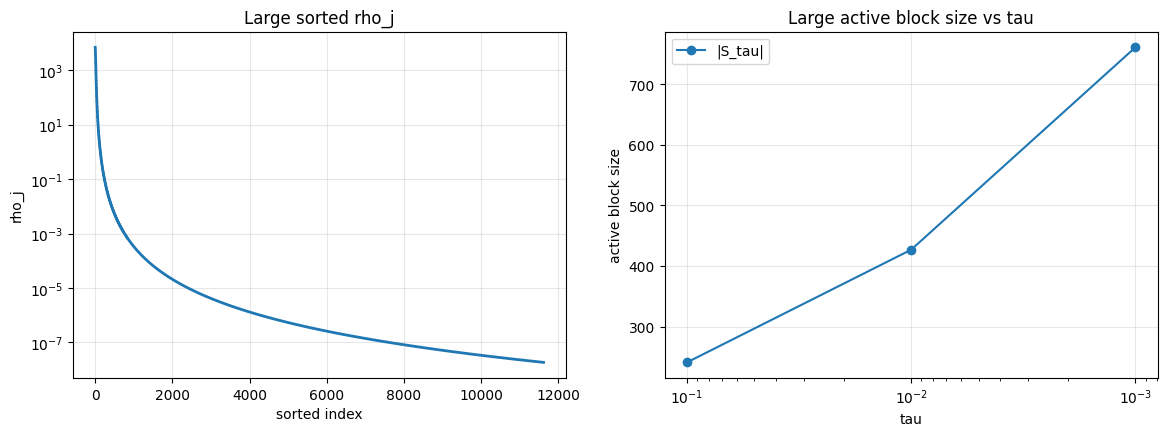

,variant,build_method,top_k,tau,block_size,size_S,setup_time,setup_time_iqr,time_build_A_SS,time_build_A_SS_iqr,time_build_diag,time_build_diag_iqr,time_cholesky_precond,time_cholesky_precond_iqr,solve_time,solve_time_iqr,cold_total_time,cold_total_time_iqr,amortized_solve_time,amortized_solve_time_iqr,iters,relres_orig,rmse_train,test_true_rmse,objective_gap,time_predict_total,setup_matvec_equiv,avg_matvec_time,avg_precond_time,eig_method_used,mu
0,pure_eigenpro_large,eigenpro,8.0,NaN,NaN,NaN,0.076425,0.001394,NaN,NaN,NaN,NaN,NaN,NaN,0.229292,0.000967,0.305717,0.001697,0.229292,0.000967,65,4.004229e-09,0.019626,0.001727,8.542785e-11,0.005548,NaN,0.002856,0.000170,eigsh,186.089630
1,pure_eigenpro_large,eigenpro,4.0,NaN,NaN,NaN,0.073592,0.000113,NaN,NaN,NaN,NaN,NaN,NaN,0.297722,0.002092,0.371313,0.002095,0.297722,0.002092,85,9.464289e-09,0.019626,0.001727,3.514375e-10,0.006309,NaN,0.002856,0.000143,eigsh,699.046702
2,baseline_cg_large,none,0.0,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.411977,0.003976,0.411977,0.003976,0.411977,0.003976,121,6.653171e-09,0.019626,0.001727,8.244216e-11,0.005758,NaN,0.002919,0.000000,NaN,NaN
3,active_block_matrix_free_tau,basis_matvec,NaN,0.100,241.0,241.0,0.937904,0.013045,0.934891,0.012889,0.000090,0.000025,0.002955,0.000147,0.026586,0.000221,0.964828,0.012993,0.026586,0.000221,6,2.980501e-09,0.019626,0.001727,2.819931e-12,0.005739,241.0,0.003025,0.000284,NaN,NaN
4,active_block_matrix_free_tau,basis_matvec,NaN,0.010,427.0,427.0,1.667826,0.017203,1.656614,0.016818,0.000073,0.000007,0.011674,0.000646,0.022441,0.000468,1.689827,0.016955,0.022441,0.000468,4,5.699394e-09,0.019626,0.001727,2.374027e-12,0.005706,427.0,0.003218,0.000965,NaN,NaN
5,active_block_matrix_free_tau,basis_matvec,NaN,0.001,761.0,761.0,2.975068,0.021415,2.944532,0.020852,0.000144,0.000003,0.030397,0.000562,0.022730,0.000827,2.997798,0.022242,0.022730,0.000827,3,3.175880e-09,0.019626,0.001727,2.869747e-11,0.005693,761.0,0.003120,0.002577,NaN,NaN


In [240]:
large_problem = build_large_problem(
    eps=COMBO_EPS_LARGE,
    n_samples=COMBO_N_LARGE,
    seed=LARGE_SEED,
    use_streaming=True,
    chunk_size=LARGE_STREAM_CHUNK_SIZE,
    materialize_features=False,
)
large_solver = large_problem["solver"]
large_state = large_problem["state"]
large_b = large_problem["b"]
large_D = large_problem["D"]
large_y = large_problem["y"]
large_y_test = large_problem["y_test"]
large_N = large_problem["N"]
large_M = large_problem["M"]
large_grid_summary = pd.DataFrame([summarize_problem_grid(large_problem)])
large_scale_plan_df = summarize_large_scale_cases(LARGE_SCALE_CASES)

large_counted = CountedOperator(large_solver, large_state)
large_full_beta, large_full_it, large_full_relres, _large_full_hist = pcg_solve(
    large_counted.apply,
    large_b,
    tol=1e-11,
    maxiter=6000,
    precond=None,
    store_history=False,
    return_stats=False,
)
large_full_beta = np.asarray(large_full_beta, dtype=np.complex128)
large_full_objective = summarize_large_beta_metrics_with_timing(
    large_problem,
    large_full_beta,
    reg_lambda=COMBO_REG_LAMBDA,
)["objective"]
large_rho = compute_rho(large_N, large_D, reg_lambda=COMBO_REG_LAMBDA)

large_baseline_df = solve_large_baselines(
    large_problem,
    objective_ref=large_full_objective,
    repeats=TIMING_REPEATS_LARGE,
)
large_tau_df = solve_large_active_block_sweep(
    large_problem,
    objective_ref=large_full_objective,
    taus=LARGE_ACTIVE_TAUS,
    repeats=TIMING_REPEATS_LARGE,
    build_method=LARGE_MAIN_BUILD_METHOD,
)
large_compare_df = rename_test_metric_columns(
    pd.concat([large_baseline_df, large_tau_df], ignore_index=True, sort=False)
).sort_values("cold_total_time").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].semilogy(np.sort(large_rho)[::-1], lw=2)
axes[0].set_title("Large sorted rho_j")
axes[0].set_xlabel("sorted index")
axes[0].set_ylabel("rho_j")
axes[0].grid(alpha=0.3)

if len(large_tau_df) > 0:
    axes[1].plot(large_tau_df["tau"], large_tau_df["size_S"], marker="o", label="|S_tau|")
    axes[1].set_xscale("log")
    axes[1].invert_xaxis()
axes[1].set_title("Large active block size vs tau")
axes[1].set_xlabel("tau")
axes[1].set_ylabel("active block size")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="best")
plt.show()

large_grid_summary

large_scale_plan_df

large_compare_df[[
    "variant",
    "build_method",
    "top_k",
    "tau",
    "block_size",
    "size_S",
    "setup_time",
    "setup_time_iqr",
    "time_build_A_SS",
    "time_build_A_SS_iqr",
    "time_build_diag",
    "time_build_diag_iqr",
    "time_cholesky_precond",
    "time_cholesky_precond_iqr",
    "solve_time",
    "solve_time_iqr",
    "cold_total_time",
    "cold_total_time_iqr",
    "amortized_solve_time",
    "amortized_solve_time_iqr",
    "iters",
    "relres_orig",
    "rmse_train",
    "test_true_rmse",
    "objective_gap",
    "time_predict_total",
    "setup_matvec_equiv",
    "avg_matvec_time",
    "avg_precond_time",
    "eig_method_used",
    "mu",
]]

In [241]:
large_ass_build_consistency = pd.DataFrame([
    {
        "selector": "tau=0.1",
        **compare_A_SS_builds(large_problem, active_set_from_tau(large_rho, 1e-1)),
    },
    {
        "selector": "tau=0.01",
        **compare_A_SS_builds(large_problem, active_set_from_tau(large_rho, 1e-2)),
    },
    {
        "selector": "size=128",
        **compare_A_SS_builds(large_problem, make_active_indices_from_size(large_rho, 128)),
    },
    {
        "selector": "size=256",
        **compare_A_SS_builds(large_problem, make_active_indices_from_size(large_rho, 256)),
    },
]).sort_values(["status", "max_relerr", "selector"]).reset_index(drop=True)
large_ass_build_consistency[[
    "selector",
    "size_S",
    "basis_vs_gram",
    "basis_vs_lag",
    "gram_vs_lag",
    "basis_matvec_equiv",
    "max_relerr",
    "within_tol",
    "status",
]]

large_ass_build_df = benchmark_large_A_SS_build_methods(
    large_problem,
    objective_ref=large_full_objective,
    tau_values=(1e-1, 1e-2),
    fixed_sizes=(64, 128, 256, 512),
    build_methods=("basis_matvec", "gram_dense", "unique_lags_1d"),
    repeats=TIMING_REPEATS_LARGE,
).sort_values(["selector", "cold_total_time", "method"]).reset_index(drop=True)

large_ass_build_df[[
    "method",
    "selector",
    "size_S",
    "build_A_SS_time",
    "build_A_SS_time_iqr",
    "cholesky_time",
    "cholesky_time_iqr",
    "setup_time",
    "setup_time_iqr",
    "solve_time",
    "solve_time_iqr",
    "cold_total_time",
    "cold_total_time_iqr",
    "amortized_solve_time",
    "amortized_solve_time_iqr",
    "iters",
    "relres_orig",
    "setup_matvec_equiv",
]]

,method,selector,size_S,build_A_SS_time,build_A_SS_time_iqr,cholesky_time,cholesky_time_iqr,setup_time,setup_time_iqr,solve_time,solve_time_iqr,cold_total_time,cold_total_time_iqr,amortized_solve_time,amortized_solve_time_iqr,iters,relres_orig,setup_matvec_equiv
0,gram_dense,size=128,128,0.060623,0.001896,0.001362,0.000036,0.062108,0.001939,0.054250,0.001827,0.118930,0.002481,0.054250,0.001827,14,7.275855e-09,0
1,unique_lags_1d,size=128,128,0.105077,0.001666,0.001297,0.000006,0.106422,0.001661,0.053550,0.001511,0.162498,0.001909,0.053550,0.001511,14,7.275855e-09,0
2,basis_matvec,size=128,128,0.443076,0.009276,0.001853,0.000160,0.444946,0.009462,0.053776,0.000556,0.498722,0.008905,0.053776,0.000556,14,7.275855e-09,128
3,gram_dense,size=256,256,0.131019,0.002855,0.004471,0.000178,0.135575,0.002685,0.027450,0.000432,0.163025,0.002253,0.027450,0.000432,6,1.582162e-09,0
4,unique_lags_1d,size=256,256,0.212984,0.001746,0.004325,0.000179,0.217479,0.001598,0.027591,0.000263,0.245475,0.001659,0.027591,0.000263,6,1.582162e-09,0
5,basis_matvec,size=256,256,0.883914,0.010839,0.004432,0.000198,0.888285,0.010738,0.029051,0.001096,0.917488,0.009717,0.029051,0.001096,6,1.582162e-09,256
6,gram_dense,size=512,512,0.290347,0.010350,0.015592,0.000615,0.305221,0.010131,0.023350,0.000842,0.328572,0.009289,0.023350,0.000842,4,3.627872e-09,0
7,unique_lags_1d,size=512,512,0.439540,0.006445,0.015354,0.001245,0.454960,0.007679,0.024862,0.000694,0.480527,0.007338,0.024862,0.000694,4,3.627872e-09,0
8,basis_matvec,size=512,512,1.792254,0.009058,0.014737,0.000038,1.807148,0.009027,0.026167,0.008977,1.844495,0.005639,0.026167,0.008977,4,3.627872e-09,512
9,gram_dense,size=64,64,0.030122,0.000124,0.000827,0.000090,0.030980,0.000058,0.155222,0.000192,0.186251,0.000226,0.155222,0.000192,43,9.763747e-09,0


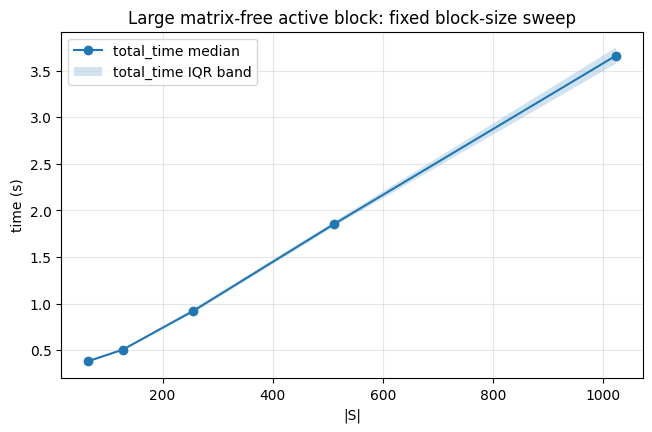

,build_method,block_size,size_S,setup_time,setup_time_iqr,time_build_A_SS,time_build_A_SS_iqr,time_build_diag,time_build_diag_iqr,time_cholesky_precond,time_cholesky_precond_iqr,solve_time,solve_time_iqr,cold_total_time,cold_total_time_iqr,amortized_solve_time,amortized_solve_time_iqr,iters,relres_orig,rmse_train,test_true_rmse,objective_gap,time_predict_total,setup_matvec_equiv,avg_matvec_time,avg_precond_time
0,basis_matvec,64,64,0.220193,0.010416,0.219158,0.010353,0.000105,0.000052,0.000792,0.000080,0.159503,0.001689,0.379696,0.012106,0.159503,0.001689,43,9.764118e-09,0.019626,0.001727,1.012160e-10,0.005644,64,0.002922,0.000194
1,basis_matvec,128,128,0.452086,0.007187,0.450577,0.007290,0.000066,0.000014,0.001462,0.000099,0.055523,0.001112,0.505667,0.007327,0.055523,0.001112,14,7.275855e-09,0.019626,0.001727,1.170025e-11,0.005850,128,0.002984,0.000227
2,basis_matvec,256,256,0.894069,0.020356,0.888950,0.019898,0.000191,0.000115,0.004928,0.000343,0.027969,0.000715,0.922038,0.021071,0.027969,0.000715,6,1.582162e-09,0.019626,0.001727,4.402782e-13,0.006326,256,0.003096,0.000561
3,basis_matvec,512,512,1.832378,0.026141,1.817205,0.026105,0.000095,0.000013,0.014568,0.000305,0.022624,0.000722,1.855002,0.025419,0.022624,0.000722,4,3.627872e-09,0.019626,0.001727,1.598853e-13,0.005843,512,0.003019,0.001316
4,basis_matvec,1024,1024,3.633692,0.082952,3.572137,0.078629,0.000073,0.000015,0.061457,0.004321,0.034707,0.006530,3.662768,0.086666,0.034707,0.006530,3,3.993192e-10,0.019626,0.001727,8.594301e-13,0.007314,1024,0.004591,0.006632


In [242]:
large_fixed_block_df = rename_test_metric_columns(
    solve_large_active_block_fixed_sizes(
        large_problem,
        objective_ref=large_full_objective,
        sizes=LARGE_FIXED_BLOCK_SIZES,
        repeats=TIMING_REPEATS_LARGE,
        build_method=LARGE_MAIN_BUILD_METHOD,
    )
).sort_values("block_size").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(large_fixed_block_df["block_size"], large_fixed_block_df["total_time"], marker="o", label="total_time median")
ax.fill_between(
    large_fixed_block_df["block_size"],
    np.maximum(large_fixed_block_df["total_time"] - large_fixed_block_df["total_time_iqr"], 0.0),
    large_fixed_block_df["total_time"] + large_fixed_block_df["total_time_iqr"],
    alpha=0.2,
    label="total_time IQR band",
)
ax.set_title("Large matrix-free active block: fixed block-size sweep")
ax.set_xlabel("|S|")
ax.set_ylabel("time (s)")
ax.grid(alpha=0.3)
ax.legend(loc="best")
plt.show()

large_fixed_block_df[[
    "build_method",
    "block_size",
    "size_S",
    "setup_time",
    "setup_time_iqr",
    "time_build_A_SS",
    "time_build_A_SS_iqr",
    "time_build_diag",
    "time_build_diag_iqr",
    "time_cholesky_precond",
    "time_cholesky_precond_iqr",
    "solve_time",
    "solve_time_iqr",
    "cold_total_time",
    "cold_total_time_iqr",
    "amortized_solve_time",
    "amortized_solve_time_iqr",
    "iters",
    "relres_orig",
    "rmse_train",
    "test_true_rmse",
    "objective_gap",
    "time_predict_total",
    "setup_matvec_equiv",
    "avg_matvec_time",
    "avg_precond_time",
]]

### Reading Guide For The Completed Supplement

Recommended reading order for the completed supplement:

1. `dense_stable_df`
   - verifies that the medium-scale conclusion still holds under repeated median timing;
   - this trimmed version keeps `baseline`, `jacobi`, `pure_eigenpro`, and `active_block` only.

2. `large_grid_summary`
   - this is the formal grid-parameter summary pulled from the same `choose_grid_params(...)` path used by `EFGPSolver.precompute(...)` / `precompute_streaming(...)`;
   - use it to report `eps / h / hm / mtot / M` together with kernel hyperparameters.

3. `large_scale_plan_df`
   - this is the staged scale-up roadmap for larger `M` and larger `N`;
   - the intended execution order is `N=1e5, M~1e4`, then `N=1e6, M~1e4`, then `N=1e6, M~5e4`.

4. `large_compare_df`
   - this is now the million-scale-friendly main comparison table;
   - active block in this table defaults to `basis_matvec`, because it avoids materializing `F_train` and remains executable at `N=10^6`.

5. `large_ass_build_consistency`
   - this is the explicit numerical consistency table for `basis_matvec`, `gram_dense`, and `unique_lags_1d`;
   - treat errors in the `1e-12 ~ 1e-10` range as consistent, and keep `unique_lags_1d` out of the main conclusion if it exceeds that range.

6. `large_ass_build_df`
   - this remains the `A_SS construction benchmark` table for the current moderate-`N` reference case;
   - use it to compare the cold-start and amortized trade-offs of `basis_matvec`, `gram_dense`, and `unique_lags_1d`.

7. `large_fixed_block_df`
   - isolates the effect of block size `|S|` from the threshold rule `tau` under the same million-scale-friendly default build path;
   - use it to decide whether small blocks are better for cold-start while larger blocks are better for repeated solves.

What to look for:

- whether the main large pipeline avoids any hard dependency on explicit `F_train / F_test` matrices;
- whether `basis_matvec` remains the safest default when extrapolating to `N=10^6`;
- whether `gram_dense` should now be framed as a moderate-`N` reference implementation rather than the universal default;
- whether `unique_lags_1d` is numerically aligned enough to justify future optimization work.


In [247]:
from efgp_eigenpro_py.discretization import basis_weights, choose_grid_params
from efgp_eigenpro_py.kernels import make_matern, make_squared_exponential

# Self-contained helper: explicitly specify dim / kernel / eps / lambda / N / tau / L
# for each case. No dependence on COMBO_* or earlier notebook parameter blocks.
KERNEL_BUILDERS = {
    "matern": make_matern,
    "squared_exponential": make_squared_exponential,
}


def _normalize_domain_length(L):
    if np.isscalar(L):
        return float(L), float(L)
    L_arr = np.asarray(L, dtype=np.float64).reshape(-1)
    return float(np.max(L_arr)), L_arr.tolist()


def build_kernel_from_case(case):
    if "kernel" in case:
        kernel = case["kernel"]
        if "dim" in case and int(case["dim"]) != int(getattr(kernel, "dim", -1)):
            raise ValueError("case['dim'] does not match case['kernel'].dim")
        return kernel
    builder_key = str(case["kernel_builder"])
    if builder_key not in KERNEL_BUILDERS:
        raise ValueError(f"unknown kernel_builder={builder_key!r}")
    kwargs = dict(case.get("kernel_kwargs", {}))
    kwargs["dim"] = int(case["dim"])
    return KERNEL_BUILDERS[builder_key](**kwargs)


def summarize_active_sizes_for_case(case):
    kernel = build_kernel_from_case(case)
    eps = float(case["eps"])
    reg_lambda = float(case["reg_lambda"])
    N = int(case["N"])
    taus = list(case["taus"])
    l2scaled = bool(case.get("l2scaled", True))
    label = str(case.get("label", "case"))
    L_scalar, L_report = _normalize_domain_length(case.get("L", 1.0))

    grid = choose_grid_params(kernel, eps, L_scalar, l2scaled=l2scaled)
    D = np.asarray(basis_weights(kernel, grid.xis, grid.h).reshape(-1), dtype=np.float64)
    rho = compute_rho(N, D, reg_lambda=reg_lambda)

    summary_df = pd.DataFrame([
        {
            "label": label,
            "kernel_family": str(getattr(kernel, "fam", type(kernel).__name__)),
            "dim": int(getattr(kernel, "dim", -1)),
            "lengthscale": float(getattr(kernel, "lengthscale", np.nan)),
            "nu": np.nan if getattr(kernel, "nu", None) is None else float(kernel.nu),
            "variance": float(getattr(kernel, "variance", np.nan)),
            "l2scaled": l2scaled,
            "N": N,
            "eps": eps,
            "lambda": reg_lambda,
            "L": L_report,
            "L_scalar": L_scalar,
            "h": float(grid.h),
            "hm": int(grid.hm),
            "mtot": int(grid.mtot),
            "M": int(D.size),
            "rho_max": float(np.max(rho)),
            "rho_min": float(np.min(rho)),
        }
    ])

    active_size_df = pd.DataFrame([
        {
            "label": label,
            "tau": float(tau),
            "size_S": int(active_set_from_tau(rho, tau).size),
            "active_fraction": float(active_set_from_tau(rho, tau).size / max(D.size, 1)),
        }
        for tau in taus
    ])
    return summary_df, active_size_df


ACTIVE_SIZE_CASES = [
    {
        "label": "synthetic_n1e8_matern_d1_nu1p5_ls0p1_eps1e-7",
        "dim": 2,
        "kernel_builder": "matern",
        "kernel_kwargs": {"lengthscale": 0.1, "nu": 1.5, "variance": 1.0},
        "eps": 1e-7,
        "reg_lambda": 0.1,
        "N": 1000_000_000,
        "taus": [1000,100,10,1,1e-1, 1e-2, 1e-3, 1e-4],
        "L": 1.0,
        "l2scaled": True,
    },
    # Example: change dim directly here.
    # {
    #     "label": "synthetic_n1e7_matern_d2_nu1p5_ls0p1_eps1e-10",
    #     "dim": 2,
    #     "kernel_builder": "matern",
    #     "kernel_kwargs": {"lengthscale": 0.1, "nu": 1.5, "variance": 1.0},
    #     "eps": 1e-10,
    #     "reg_lambda": 0.1,
    #     "N": 10_000_000,
    #     "taus": [1e-1, 1e-2, 1e-3, 1e-4],
    #     "L": [1.0, 1.0],
    #     "l2scaled": True,
    # },
    # {
    #     "label": "synthetic_n1e7_sqexp_d3_ls0p05_eps1e-12",
    #     "dim": 3,
    #     "kernel_builder": "squared_exponential",
    #     "kernel_kwargs": {"lengthscale": 0.05, "variance": 1.0},
    #     "eps": 1e-12,
    #     "reg_lambda": 0.1,
    #     "N": 10_000_000,
    #     "taus": [1e-1, 1e-2, 1e-3, 1e-4],
    #     "L": [1.0, 1.0, 1.0],
    #     "l2scaled": True,
    # },
]

summary_frames = []
active_size_frames = []
for case in ACTIVE_SIZE_CASES:
    summary_df_i, active_size_df_i = summarize_active_sizes_for_case(case)
    summary_frames.append(summary_df_i)
    active_size_frames.append(active_size_df_i)

active_size_summary_df = pd.concat(summary_frames, ignore_index=True)
active_size_tau_df = pd.concat(active_size_frames, ignore_index=True)

print("Formal grid summary from the default EFGP m/h chooser")
display(active_size_summary_df)
print("Active-set sizes under rho_j = N |D_j|^2 / lambda")
display(active_size_tau_df)

Formal grid summary from the default EFGP m/h chooser


,label,kernel_family,dim,lengthscale,nu,variance,l2scaled,N,eps,lambda,L,L_scalar,h,hm,mtot,M,rho_max,rho_min
0,synthetic_n1e8_matern_d1_nu1p5_ls0p1_eps1e-7,matern,2,0.1,1.5,1.0,True,1000000000,1.000000e-07,0.1,1.0,1.0,0.444702,346,693,480249,1.242563e+08,0.040527


Active-set sizes under rho_j = N |D_j|^2 / lambda


,label,tau,size_S,active_fraction
0,synthetic_n1e8_matern_d1_nu1p5_ls0p1_eps1e-7,1000.0000,13053,0.027180
1,synthetic_n1e8_matern_d1_nu1p5_ls0p1_eps1e-7,100.0000,32953,0.068616
2,synthetic_n1e8_matern_d1_nu1p5_ls0p1_eps1e-7,10.0000,82961,0.172746
3,synthetic_n1e8_matern_d1_nu1p5_ls0p1_eps1e-7,1.0000,208589,0.434335
4,synthetic_n1e8_matern_d1_nu1p5_ls0p1_eps1e-7,0.1000,451497,0.940131
5,synthetic_n1e8_matern_d1_nu1p5_ls0p1_eps1e-7,0.0100,480249,1.000000
6,synthetic_n1e8_matern_d1_nu1p5_ls0p1_eps1e-7,0.0010,480249,1.000000
7,synthetic_n1e8_matern_d1_nu1p5_ls0p1_eps1e-7,0.0001,480249,1.000000
